# Pruning Strategy Comparison

Compare different pruning strategies on the 1% Bavaria demand extraction.

**Approach:** Load the unpruned baseline, apply pruning strategies post-hoc, measure quality.

**Provider-focused metrics:**
- Best distance savings per request (CDF)
- Best budget retention per request (CDF)
- Pooling reach per request (CDF)
- Provider value by degree (boxplot)
- Top-ride survival @1%/5%/10%

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
from pathlib import Path

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

BASE = Path(r'C:\Users\VWAUCCY\dev\msf\projects\Dissertation\matsim_scenarios\bavaria\output')

# Load unpruned baseline and requests
rides_unpruned = pd.read_csv(BASE / 'demand-extraction-1pct-unpruned' / 'drt_demand' / 'bavaria-30km-100pct-exmas.exmas_rides.csv')
requests = pd.read_csv(BASE / 'demand-extraction-1pct-unpruned' / 'drt_demand' / 'bavaria-30km-100pct-exmas.drt_requests.csv')

print(f'Unpruned rides: {len(rides_unpruned):,}')
print(f'Requests: {len(requests):,}')
print(f'Degree distribution:\n{rides_unpruned["degree"].value_counts().sort_index()}')

Unpruned rides: 26,703
Requests: 2,132
Degree distribution:
degree
1    2128
2    9784
3    9357
4    4195
5    1110
6     129
Name: count, dtype: int64


In [78]:
# Parse array columns from CSV
# Format: [0 | 2052] or [28395.00 | 29167.00] (pipe-separated inside brackets)

def parse_pipe_array(s, dtype=float):
    """Parse '[val1 | val2 | ...]' pipe-separated array strings."""
    if pd.isna(s) or s == '[]' or s.strip() == '':
        return []
    s = s.strip('[]')
    if not s.strip():
        return []
    parts = [x.strip() for x in s.split('|')]
    return [dtype(x) for x in parts if x]

def parse_int_array(s):
    return parse_pipe_array(s, int)

def parse_float_array(s):
    return parse_pipe_array(s, float)

In [79]:
# Enrich rides with computed columns
def enrich_rides(df, requests_df):
    """Add computed quality metrics to rides dataframe."""
    df = df.copy()
    
    # Parse arrays
    df['_requestIndices'] = df['requestIndices'].apply(parse_int_array)
    df['_remainingBudgets'] = df['remainingBudgets'].apply(parse_float_array)
    df['_detours'] = df['detours'].apply(parse_float_array)
    df['_passengerDistances'] = df['passengerDistances'].apply(parse_float_array)
    
    # Build request lookup
    req_budget = requests_df.set_index('index')['budget'].to_dict()
    req_distance = requests_df.set_index('index')['directDistance'].to_dict()
    
    # Sum of individual request distances (what solo rides would cost)
    df['sumRequestDistances'] = df['_requestIndices'].apply(
        lambda idxs: sum(req_distance.get(i, 0) for i in idxs))
    
    # Distance savings: 1 - rideDistance / sumRequestDistances
    df['distanceSavings'] = 1.0 - df['rideDistance'] / df['sumRequestDistances'].clip(lower=1e-9)
    
    # Budget retention per passenger: remainingBudget / singleRideBudget
    def calc_budget_retention(row):
        idxs = row['_requestIndices']
        budgets = row['_remainingBudgets']
        if not budgets or len(budgets) == 0:
            return np.nan
        retentions = []
        for i, idx in enumerate(idxs):
            single_budget = req_budget.get(idx, 0)
            if single_budget > 0 and i < len(budgets):
                retentions.append(budgets[i] / single_budget)
        return np.mean(retentions) if retentions else np.nan
    
    def calc_min_budget_retention(row):
        idxs = row['_requestIndices']
        budgets = row['_remainingBudgets']
        if not budgets or len(budgets) == 0:
            return np.nan
        retentions = []
        for i, idx in enumerate(idxs):
            single_budget = req_budget.get(idx, 0)
            if single_budget > 0 and i < len(budgets):
                retentions.append(budgets[i] / single_budget)
        return min(retentions) if retentions else np.nan
    
    df['avgBudgetRetention'] = df.apply(calc_budget_retention, axis=1)
    df['minBudgetRetention'] = df.apply(calc_min_budget_retention, axis=1)
    
    # Max detour across passengers
    df['maxDetour'] = df['_detours'].apply(lambda d: max(d) if d else np.nan)
    
    # Request set key (sorted indices) for grouping
    df['requestSetKey'] = df['_requestIndices'].apply(lambda x: str(sorted(x)))
    
    return df

rides = enrich_rides(rides_unpruned, requests)
# Only pooled rides (degree >= 2) for pruning analysis
pooled = rides[rides['degree'] >= 2].copy()
print(f'Pooled rides (degree >= 2): {len(pooled):,}')
print(f'\nDistance savings stats:\n{pooled["distanceSavings"].describe()}')
print(f'\nBudget retention stats:\n{pooled["avgBudgetRetention"].describe()}')

Pooled rides (degree >= 2): 24,575

Distance savings stats:
count    24575.000000
mean         0.035271
std          0.225610
min         -1.284480
25%         -0.083658
50%          0.038830
75%          0.187096
max          0.663035
Name: distanceSavings, dtype: float64

Budget retention stats:
count    24575.000000
mean         0.913428
std          0.068122
min          0.371527
25%          0.890735
50%          0.932057
75%          0.958510
max          1.003743
Name: avgBudgetRetention, dtype: float64


In [80]:
# --- Pruning Strategies ---
# Each strategy takes the full pooled rides df and returns a filtered df

def prune_none(df):
    """No pruning - baseline."""
    return df

def prune_fraction(df, fraction=0.3, min_keep=3):
    """Per-request-set fraction pruning (current default)."""
    kept = []
    for key, group in df.groupby('requestSetKey'):
        group_sorted = group.sort_values('rideDistance')
        n = len(group_sorted)
        keep = max(int(np.ceil(n * fraction)), min_keep)
        keep = min(keep, n)
        kept.append(group_sorted.iloc[:keep])
    return pd.concat(kept, ignore_index=True)

def prune_distance_savings(df, scale=0.25, max_saving=0.75, min_degree=2):
    """Distance-savings gate: reject rides that don't save enough.
    requiredSaving(degree) = scale * log2(degree), clamped to max_saving."""
    def passes(row):
        d = row['degree']
        if d < min_degree:
            return True
        required = min(scale * np.log2(d), max_saving)
        return row['distanceSavings'] >= required
    return df[df.apply(passes, axis=1)].copy()

def prune_max_per_set(df, max_keep=5):
    """Hard cap per request set, keep best by rideDistance."""
    kept = []
    for key, group in df.groupby('requestSetKey'):
        group_sorted = group.sort_values('rideDistance')
        kept.append(group_sorted.iloc[:max_keep])
    return pd.concat(kept, ignore_index=True)

def prune_combined(df, fraction=0.3, min_keep=3, dist_scale=0.25, max_saving=0.75):
    """Combined: distance-savings gate then fraction pruning."""
    df2 = prune_distance_savings(df, dist_scale, max_saving)
    return prune_fraction(df2, fraction, min_keep)

# Define strategies to compare
strategies = {
    'Unpruned': lambda df: prune_none(df),
    'Fraction 0.3 (min=3)': lambda df: prune_fraction(df, 0.3, 3),
    'Fraction 0.5 (min=3)': lambda df: prune_fraction(df, 0.5, 3),
    'Fraction 0.3 (min=1)': lambda df: prune_fraction(df, 0.3, 1),
    'DistSavings 0.15': lambda df: prune_distance_savings(df, 0.15),
    'DistSavings 0.25': lambda df: prune_distance_savings(df, 0.25),
    'DistSavings 0.35': lambda df: prune_distance_savings(df, 0.35),
    'MaxPerSet 3': lambda df: prune_max_per_set(df, 3),
    'MaxPerSet 5': lambda df: prune_max_per_set(df, 5),
    'MaxPerSet 1': lambda df: prune_max_per_set(df, 1),
    'Combined (default)': lambda df: prune_combined(df, 0.3, 3, 0.25),
    'Aggressive': lambda df: prune_combined(df, 0.3, 1, 0.35),
}

# Apply all strategies
results = {}
for name, fn in strategies.items():
    pruned = fn(pooled)
    results[name] = pruned
    print(f'{name:30s}: {len(pruned):>8,} rides ({len(pruned)/len(pooled)*100:5.1f}%)')

Unpruned                      :   24,575 rides (100.0%)
Fraction 0.3 (min=3)          :   22,894 rides ( 93.2%)
Fraction 0.5 (min=3)          :   23,071 rides ( 93.9%)
Fraction 0.3 (min=1)          :   17,097 rides ( 69.6%)
DistSavings 0.15              :    4,120 rides ( 16.8%)
DistSavings 0.25              :    1,248 rides (  5.1%)
DistSavings 0.35              :      327 rides (  1.3%)
MaxPerSet 3                   :   22,825 rides ( 92.9%)
MaxPerSet 5                   :   23,892 rides ( 97.2%)
MaxPerSet 1                   :   16,140 rides ( 65.7%)
Combined (default)            :    1,093 rides (  4.4%)
Aggressive                    :      179 rides (  0.7%)


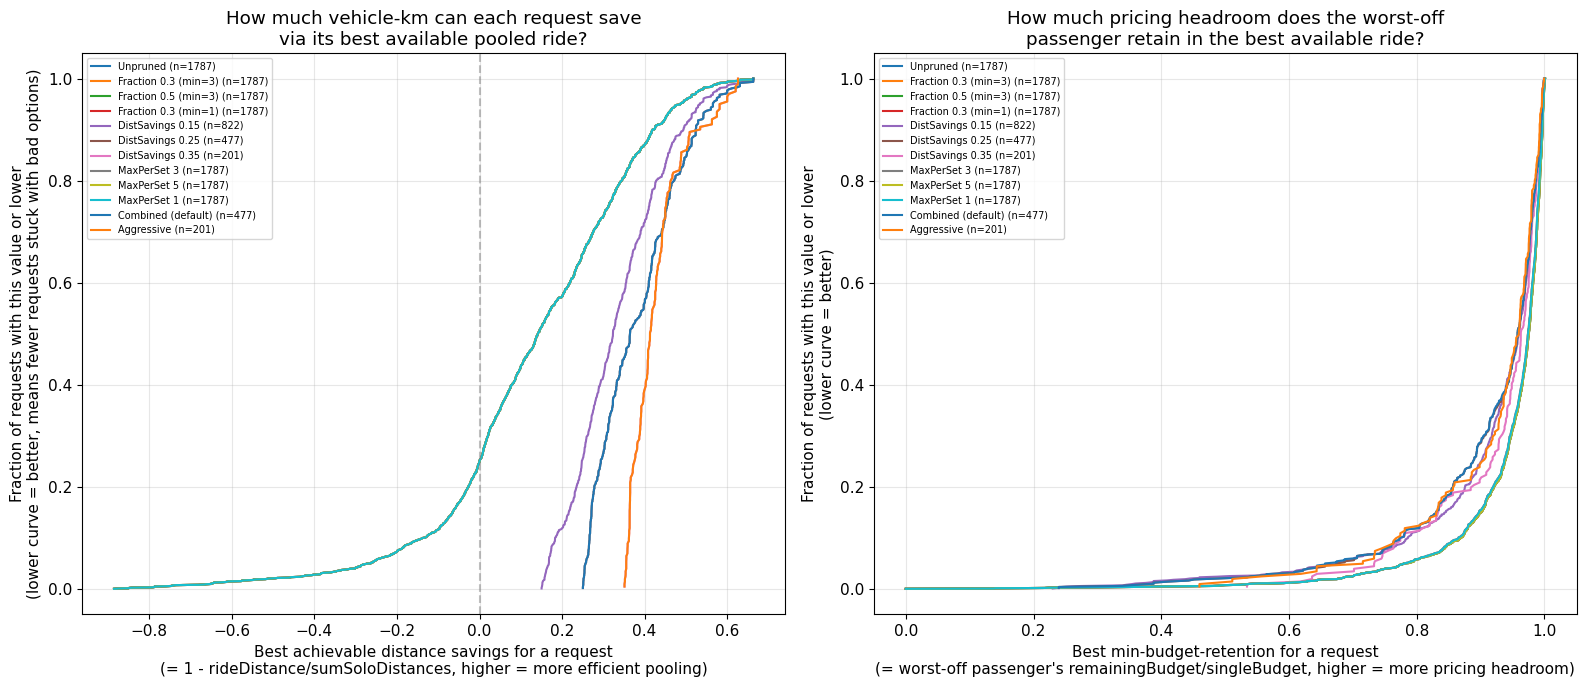

INTERPRETATION GUIDE:
- Left plot (distance savings): The further RIGHT a curve goes, the better.
  A request with savings=0.3 means pooling saves 30% of vehicle-km vs solo rides.
  If a curve DROPS (fewer requests covered), that strategy killed pooling options.
  Ideal: same curve shape as Unpruned, just with fewer rides in the dataset.

- Right plot (min budget retention): Higher values = provider can charge more.
  retention=0.9 means even the worst-off passenger keeps 90% of their WTP advantage.
  If strategies DROP request count (n=822 vs n=1787), those requests lost ALL rides.


In [81]:
# --- Metric 1: Best Distance Savings & Min Budget Retention per Request (CDF) ---
# 
# How to read these CDFs:
# - X-axis: the metric value (e.g., distance savings of the best ride for each request)
# - Y-axis: fraction of requests that have this value OR WORSE
# - Higher curve = more requests have lower values = worse
# - Curves shifting RIGHT = better (requests have access to higher-quality rides)
# - If a pruning curve overlaps with "Unpruned", that metric is fully preserved

def best_metric_per_request(df, metric='distanceSavings', agg='max'):
    """For each request, find the best value of `metric` across all rides containing it."""
    rows = []
    for _, row in df.iterrows():
        val = row[metric]
        for req_idx in row['_requestIndices']:
            rows.append({'requestIndex': req_idx, metric: val})
    if not rows:
        return pd.Series(dtype=float)
    expanded = pd.DataFrame(rows)
    if agg == 'max':
        return expanded.groupby('requestIndex')[metric].max()
    else:
        return expanded.groupby('requestIndex')[metric].min()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Distance savings CDF
ax = axes[0]
for name, df in results.items():
    best = best_metric_per_request(df, 'distanceSavings', 'max')
    if len(best) > 0:
        sorted_vals = np.sort(best.values)
        cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
        ax.plot(sorted_vals, cdf, label=f'{name} (n={len(best)})')
ax.set_xlabel('Best achievable distance savings for a request\n'
              '(= 1 - rideDistance/sumSoloDistances, higher = more efficient pooling)')
ax.set_ylabel('Fraction of requests with this value or lower\n'
              '(lower curve = better, means fewer requests stuck with bad options)')
ax.set_title('How much vehicle-km can each request save\nvia its best available pooled ride?')
ax.legend(fontsize=7, loc='upper left')
ax.grid(True, alpha=0.3)
ax.axvline(x=0, color='grey', linestyle='--', alpha=0.5, label='break-even (no savings)')

# Min budget retention CDF
ax = axes[1]
for name, df in results.items():
    best = best_metric_per_request(df, 'minBudgetRetention', 'max')
    best = best.dropna()
    if len(best) > 0:
        sorted_vals = np.sort(best.values)
        cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
        ax.plot(sorted_vals, cdf, label=f'{name} (n={len(best)})')
ax.set_xlabel('Best min-budget-retention for a request\n'
              '(= worst-off passenger\'s remainingBudget/singleBudget, higher = more pricing headroom)')
ax.set_ylabel('Fraction of requests with this value or lower\n'
              '(lower curve = better)')
ax.set_title('How much pricing headroom does the worst-off\npassenger retain in the best available ride?')
ax.legend(fontsize=7, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(BASE / 'pruning_comparison_savings_budget.png'), dpi=150)
plt.show()

# Key interpretation help
print("INTERPRETATION GUIDE:")
print("- Left plot (distance savings): The further RIGHT a curve goes, the better.")
print("  A request with savings=0.3 means pooling saves 30% of vehicle-km vs solo rides.")
print("  If a curve DROPS (fewer requests covered), that strategy killed pooling options.")
print("  Ideal: same curve shape as Unpruned, just with fewer rides in the dataset.")
print()
print("- Right plot (min budget retention): Higher values = provider can charge more.")
print("  retention=0.9 means even the worst-off passenger keeps 90% of their WTP advantage.")
print("  If strategies DROP request count (n=822 vs n=1787), those requests lost ALL rides.")

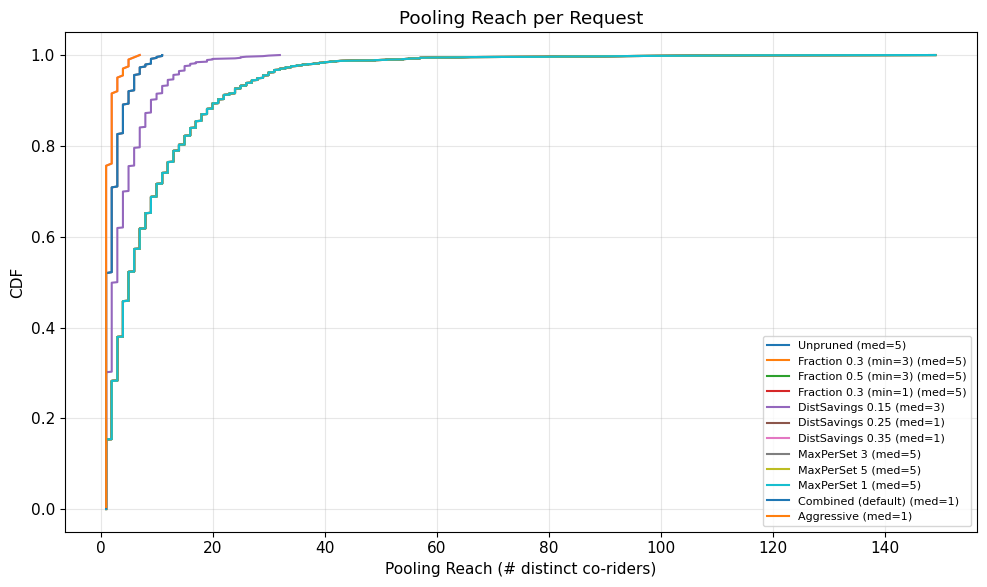

In [82]:
# --- Metric 2: Pooling Reach per Request (CDF) ---

def pooling_reach_per_request(df):
    """For each request, count distinct other requests it can share a ride with."""
    co_riders = {}  # request_idx -> set of co-rider indices
    for _, row in df.iterrows():
        idxs = row['_requestIndices']
        for i in idxs:
            if i not in co_riders:
                co_riders[i] = set()
            co_riders[i].update(j for j in idxs if j != i)
    return pd.Series({k: len(v) for k, v in co_riders.items()})

fig, ax = plt.subplots(figsize=(10, 6))
for name, df in results.items():
    reach = pooling_reach_per_request(df)
    if len(reach) > 0:
        sorted_vals = np.sort(reach.values)
        cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
        ax.plot(sorted_vals, cdf, label=f'{name} (med={np.median(sorted_vals):.0f})')
ax.set_xlabel('Pooling Reach (# distinct co-riders)')
ax.set_ylabel('CDF')
ax.set_title('Pooling Reach per Request')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(BASE / 'pruning_comparison_reach.png'), dpi=150)
plt.show()

In [83]:
# --- Metric 3: All Metrics per Degree per Strategy ---

# Compute per-degree stats for each strategy
def compute_per_degree_stats(df):
    """Compute all quality metrics grouped by degree."""
    rows = []
    for d in sorted(df['degree'].unique()):
        sub = df[df['degree'] == d]
        rows.append({
            'degree': d,
            'rides': len(sub),
            'distSavings_mean': sub['distanceSavings'].mean(),
            'distSavings_med': sub['distanceSavings'].median(),
            'avgBudgetRet_med': sub['avgBudgetRetention'].median(),
            'minBudgetRet_med': sub['minBudgetRetention'].median(),
            'sumRemBudgets_med': sub['_remainingBudgets'].apply(sum).median(),
            'maxDetour_med': sub['maxDetour'].median(),
            'rideDistance_med': sub['rideDistance'].median(),
        })
    return pd.DataFrame(rows).set_index('degree')

all_stats = {name: compute_per_degree_stats(df) for name, df in results.items()}

# Print comprehensive table
for name in results:
    s = all_stats[name]
    print(f'\n=== {name} ({len(results[name]):,} rides) ===')
    print(s.to_string(float_format=lambda x: f'{x:.3f}'))
    print()


=== Unpruned (24,575 rides) ===
        rides  distSavings_mean  distSavings_med  avgBudgetRet_med  minBudgetRet_med  sumRemBudgets_med  maxDetour_med  rideDistance_med
degree                                                                                                                                  
2        9784            -0.052           -0.034             0.943             0.916              4.990          1.150         25111.400
3        9357             0.055            0.055             0.926             0.867              7.030          1.250         33612.400
4        4195             0.139            0.160             0.924             0.847              8.970          1.280         41526.700
5        1110             0.220            0.242             0.930             0.851             10.770          1.290         34632.900
6         129             0.313            0.342             0.929             0.828             11.800          1.300         27631.200


=== Fr

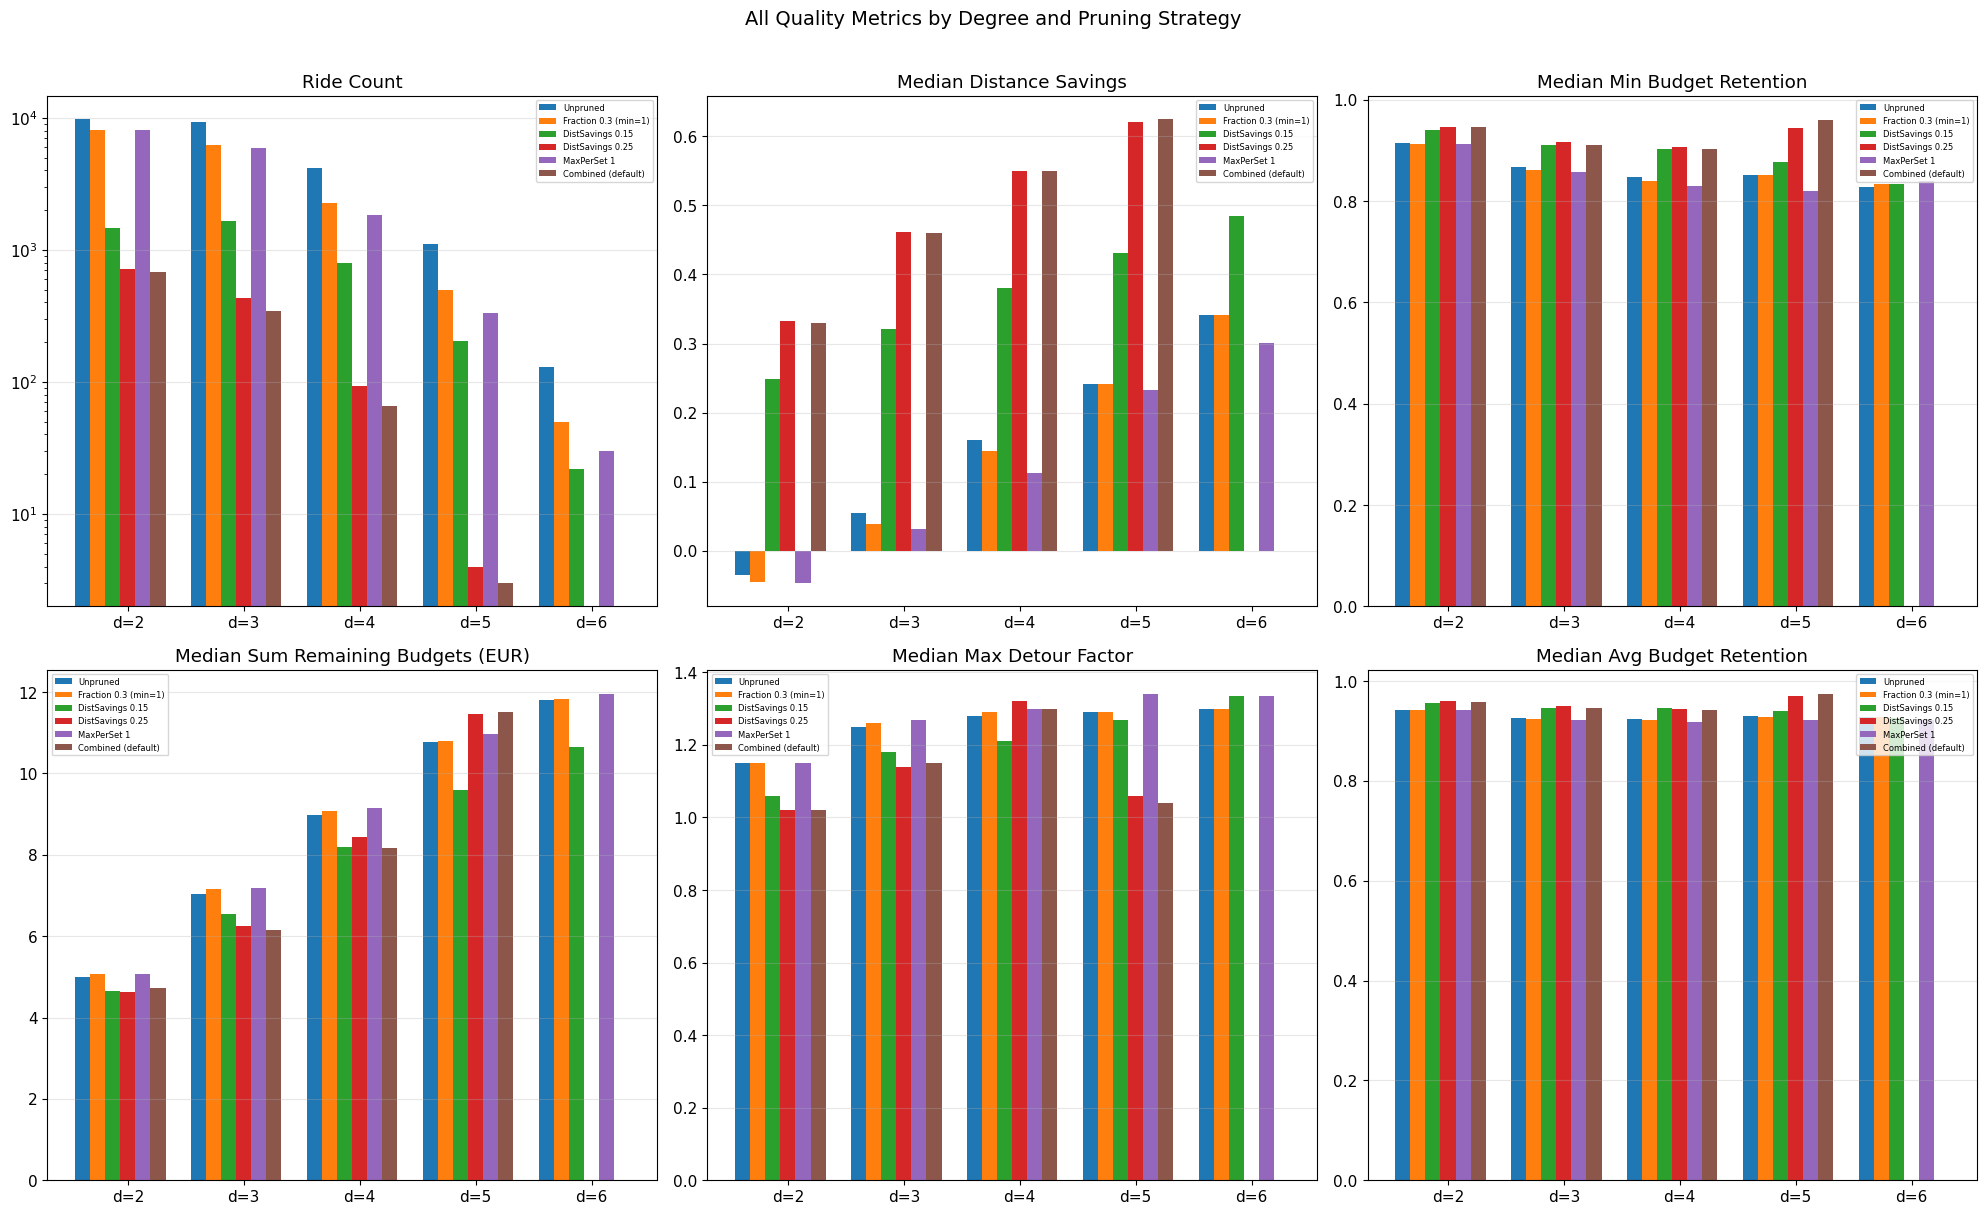

In [84]:
# --- Visual: All Metrics per Degree (grouped bar charts) ---

metrics = [
    ('rides', 'Ride Count', False),
    ('distSavings_med', 'Median Distance Savings', False),
    ('minBudgetRet_med', 'Median Min Budget Retention', False),
    ('sumRemBudgets_med', 'Median Sum Remaining Budgets (EUR)', False),
    ('maxDetour_med', 'Median Max Detour Factor', True),  # lower is better
    ('avgBudgetRet_med', 'Median Avg Budget Retention', False),
]

subset = ['Unpruned', 'Fraction 0.3 (min=1)', 'DistSavings 0.15', 'DistSavings 0.25', 'MaxPerSet 1', 'Combined (default)']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
degrees = sorted(pooled['degree'].unique())
x = np.arange(len(degrees))
width = 0.13

for ax, (metric, title, invert) in zip(axes.flat, metrics):
    for i, name in enumerate(subset):
        s = all_stats[name]
        vals = [s.loc[d, metric] if d in s.index else 0 for d in degrees]
        ax.bar(x + i * width, vals, width, label=name)
    ax.set_xticks(x + width * len(subset) / 2)
    ax.set_xticklabels([f'd={d}' for d in degrees])
    ax.set_title(title)
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.3, axis='y')
    if metric == 'rides':
        ax.set_yscale('log')

plt.suptitle('All Quality Metrics by Degree and Pruning Strategy', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(str(BASE / 'pruning_comparison_all_metrics_by_degree.png'), dpi=150, bbox_inches='tight')
plt.show()

In [85]:
# --- Metric 4: Request-Set-Level Survival ---
# The MIP picks ONE ride per request set. So the right question is:
# does each set's BEST ride survive pruning? Not how many variants survive.

def best_ride_per_set_survival(baseline_df, pruned_df, metric, percentiles=[0.01, 0.05, 0.10]):
    """For each request set, take its best ride (by metric). 
    What fraction of the globally top-K% best-per-set rides survive pruning?"""
    # Best ride per set in baseline
    baseline_best = baseline_df.loc[baseline_df.groupby('requestSetKey')[metric].idxmax()]
    # Best ride per set in pruned (if set still exists)
    pruned_best = pruned_df.loc[pruned_df.groupby('requestSetKey')[metric].idxmax()]
    
    baseline_best_sorted = baseline_best.sort_values(metric, ascending=False)
    pruned_set_keys = set(pruned_best['requestSetKey'])
    
    results_surv = {}
    for pct in percentiles:
        n = max(1, int(len(baseline_best_sorted) * pct))
        top_sets = set(baseline_best_sorted.iloc[:n]['requestSetKey'])
        survived = len(top_sets & pruned_set_keys)
        results_surv[f'top-{pct*100:.0f}%'] = survived / len(top_sets)
    return results_surv

def request_coverage(df):
    """How many unique requests appear in at least one ride?"""
    all_reqs = set()
    for idxs in df['_requestIndices']:
        all_reqs.update(idxs)
    return len(all_reqs)

total_requests = request_coverage(pooled)
total_sets = pooled['requestSetKey'].nunique()

print('=== Request-Set Survival (Distance Savings) ===')
print('Does each passenger group\'s BEST ride survive? (MIP only picks one per set)')
print(f'{"Strategy":30s} {"top-1%":>8s} {"top-5%":>8s} {"top-10%":>8s} {"sets":>8s} {"reqs":>6s} {"rides":>8s}')
print('-' * 82)
for name, df in results.items():
    surv = best_ride_per_set_survival(pooled, df, 'distanceSavings')
    n_sets = df['requestSetKey'].nunique()
    n_reqs = request_coverage(df)
    print(f'{name:30s} {surv["top-1%"]:8.1%} {surv["top-5%"]:8.1%} {surv["top-10%"]:8.1%} {n_sets:>8,} {n_reqs:>6,} {len(df):>8,}')

print()
print('=== Request-Set Survival (Min Budget Retention) ===')
print(f'{"Strategy":30s} {"top-1%":>8s} {"top-5%":>8s} {"top-10%":>8s}')
print('-' * 60)
for name, df in results.items():
    surv = best_ride_per_set_survival(pooled, df, 'minBudgetRetention')
    print(f'{name:30s} {surv["top-1%"]:8.1%} {surv["top-5%"]:8.1%} {surv["top-10%"]:8.1%}')

print()
print('=== Request-Set Survival (Sum Remaining Budgets) ===')
print(f'{"Strategy":30s} {"top-1%":>8s} {"top-5%":>8s} {"top-10%":>8s}')
print('-' * 60)
for name, df in results.items():
    df_tmp = df.copy()
    df_tmp['_sumRemBudgets'] = df_tmp['_remainingBudgets'].apply(sum)
    pooled_tmp = pooled.copy()
    pooled_tmp['_sumRemBudgets'] = pooled_tmp['_remainingBudgets'].apply(sum)
    surv = best_ride_per_set_survival(pooled_tmp, df_tmp, '_sumRemBudgets')
    print(f'{name:30s} {surv["top-1%"]:8.1%} {surv["top-5%"]:8.1%} {surv["top-10%"]:8.1%}')

=== Request-Set Survival (Distance Savings) ===
Does each passenger group's BEST ride survive? (MIP only picks one per set)
Strategy                         top-1%   top-5%  top-10%     sets   reqs    rides
----------------------------------------------------------------------------------
Unpruned                         100.0%   100.0%   100.0%   16,140  1,787   24,575
Fraction 0.3 (min=3)             100.0%   100.0%   100.0%   16,140  1,787   22,894
Fraction 0.5 (min=3)             100.0%   100.0%   100.0%   16,140  1,787   23,071
Fraction 0.3 (min=1)             100.0%   100.0%   100.0%   16,140  1,787   17,097
DistSavings 0.15                 100.0%    98.5%    88.7%    2,088    822    4,120
DistSavings 0.25                  70.2%    45.5%    35.5%      600    477    1,248
DistSavings 0.35                  15.5%    18.2%     9.1%      147    201      327
MaxPerSet 3                      100.0%   100.0%   100.0%   16,140  1,787   22,825
MaxPerSet 5                      100.0%   100.

=== Best Distance Savings per Request Set — Percentiles ===
  P  0: -1.284 (adds 128.4% distance)
  P 10: -0.299 (adds 29.9% distance)
  P 20: -0.163 (adds 16.3% distance)
  P 30: -0.093 (adds 9.3% distance)
  P 40: -0.042 (adds 4.2% distance)
  P 50: -0.001 (adds 0.1% distance)
  P 60: +0.040 (saves 4.0%)
  P 70: +0.092 (saves 9.2%)
  P 80: +0.162 (saves 16.2%)
  P 90: +0.256 (saves 25.6%)
  P 95: +0.332 (saves 33.2%)
  P 99: +0.467 (saves 46.7%)
  P100: +0.663 (saves 66.3%)

       Bin   Sets        Savings range
----------------------------------------
     P0-10   1614 -1.284 to -0.299
    P10-20   1614 -0.299 to -0.163
    P20-30   1614 -0.163 to -0.093
    P30-40   1614 -0.093 to -0.042
    P40-50   1614 -0.042 to -0.001
    P50-60   1614 -0.001 to +0.040
    P60-70   1614 +0.040 to +0.092
    P70-80   1614 +0.092 to +0.162
    P80-90   1614 +0.162 to +0.256
    P90-95    807 +0.256 to +0.332
    P95-99    645 +0.333 to +0.467
   P99-100    162 +0.467 to +0.663

=== Set Survival 

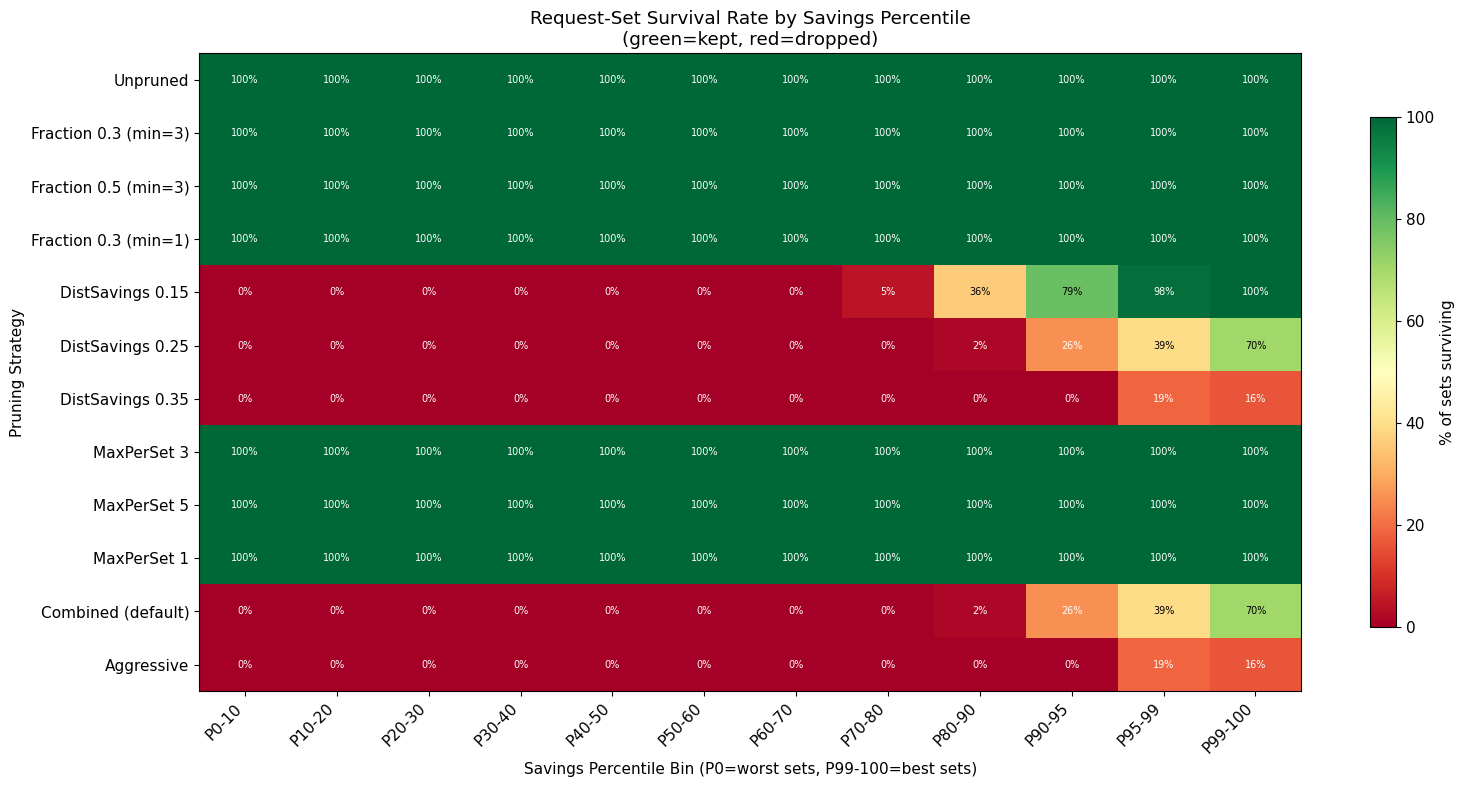

In [86]:
# --- Metric 4c: Set Survival by Savings Percentile ---
# Instead of arbitrary tiers, use the actual distribution of best savings per set.
# Split sets into percentile bins by their best distance savings, then check
# how many sets in each bin survive each pruning strategy.

# Best savings per request set (baseline)
baseline_best_per_set = pooled.loc[pooled.groupby('requestSetKey')['distanceSavings'].idxmax()].copy()
baseline_best_per_set = baseline_best_per_set.sort_values('distanceSavings')

# Assign percentile rank (0-100) based on best savings
baseline_best_per_set['pctRank'] = (
    baseline_best_per_set['distanceSavings'].rank(pct=True) * 100
)

# Show the savings values at key percentiles
print('=== Best Distance Savings per Request Set — Percentiles ===')
for p in [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 99, 100]:
    val = baseline_best_per_set['distanceSavings'].quantile(p / 100)
    print(f'  P{p:>3d}: {val:+.3f} ({"saves " + f"{val*100:.1f}%" if val > 0 else "adds " + f"{-val*100:.1f}% distance"})')

# Bin into deciles + top 5% + top 1%
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 99, 100]
bin_labels = []
for i in range(len(bins)-1):
    bin_labels.append(f'P{bins[i]}-{bins[i+1]}')

baseline_best_per_set['pctBin'] = pd.cut(
    baseline_best_per_set['pctRank'], 
    bins=bins, labels=bin_labels, include_lowest=True
)

# Show set counts and savings ranges per bin
print(f'\n{"Bin":>10s} {"Sets":>6s} {"Savings range":>20s}')
print('-' * 40)
for label in bin_labels:
    sub = baseline_best_per_set[baseline_best_per_set['pctBin'] == label]
    if len(sub) > 0:
        lo = sub['distanceSavings'].min()
        hi = sub['distanceSavings'].max()
        print(f'{label:>10s} {len(sub):>6d} {lo:+.3f} to {hi:+.3f}')

# Now check survival per bin per strategy
print('\n=== Set Survival Rate by Savings Percentile ===')
print('Each cell = % of sets in that percentile bin that survive pruning')
print()

header = f'{"Strategy":30s}'
for label in bin_labels:
    header += f' {label:>8s}'
header += f' {"TotalVal":>9s}'
print(header)
print('-' * len(header))

baseline_val = baseline_best_per_set['distanceSavings'].clip(lower=0).sum()

for name, df in results.items():
    pruned_sets = set(df['requestSetKey'].unique())
    row = f'{name:30s}'
    for label in bin_labels:
        sub = baseline_best_per_set[baseline_best_per_set['pctBin'] == label]
        tier_sets = set(sub['requestSetKey'])
        survived = len(tier_sets & pruned_sets)
        pct = survived / len(tier_sets) * 100 if len(tier_sets) > 0 else 0
        row += f' {pct:>7.0f}%'
    
    pruned_best = df.loc[df.groupby('requestSetKey')['distanceSavings'].idxmax()]
    total_val = pruned_best['distanceSavings'].clip(lower=0).sum()
    row += f' {total_val/baseline_val*100:>8.1f}%'
    print(row)

# Visual: heatmap-style plot
fig, ax = plt.subplots(figsize=(16, 8))
strategy_names = list(results.keys())
survival_matrix = []
for name in strategy_names:
    df = results[name]
    pruned_sets = set(df['requestSetKey'].unique())
    row = []
    for label in bin_labels:
        sub = baseline_best_per_set[baseline_best_per_set['pctBin'] == label]
        tier_sets = set(sub['requestSetKey'])
        survived = len(tier_sets & pruned_sets)
        pct = survived / len(tier_sets) * 100 if len(tier_sets) > 0 else 0
        row.append(pct)
    survival_matrix.append(row)

im = ax.imshow(survival_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)
ax.set_xticks(range(len(bin_labels)))
ax.set_xticklabels(bin_labels, rotation=45, ha='right')
ax.set_yticks(range(len(strategy_names)))
ax.set_yticklabels(strategy_names)
ax.set_xlabel('Savings Percentile Bin (P0=worst sets, P99-100=best sets)')
ax.set_ylabel('Pruning Strategy')
ax.set_title('Request-Set Survival Rate by Savings Percentile\n(green=kept, red=dropped)')

# Add text annotations
for i in range(len(strategy_names)):
    for j in range(len(bin_labels)):
        val = survival_matrix[i][j]
        color = 'white' if val < 30 or val > 80 else 'black'
        ax.text(j, i, f'{val:.0f}%', ha='center', va='center', fontsize=7, color=color)

plt.colorbar(im, label='% of sets surviving', shrink=0.8)
plt.tight_layout()
plt.savefig(str(BASE / 'pruning_survival_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

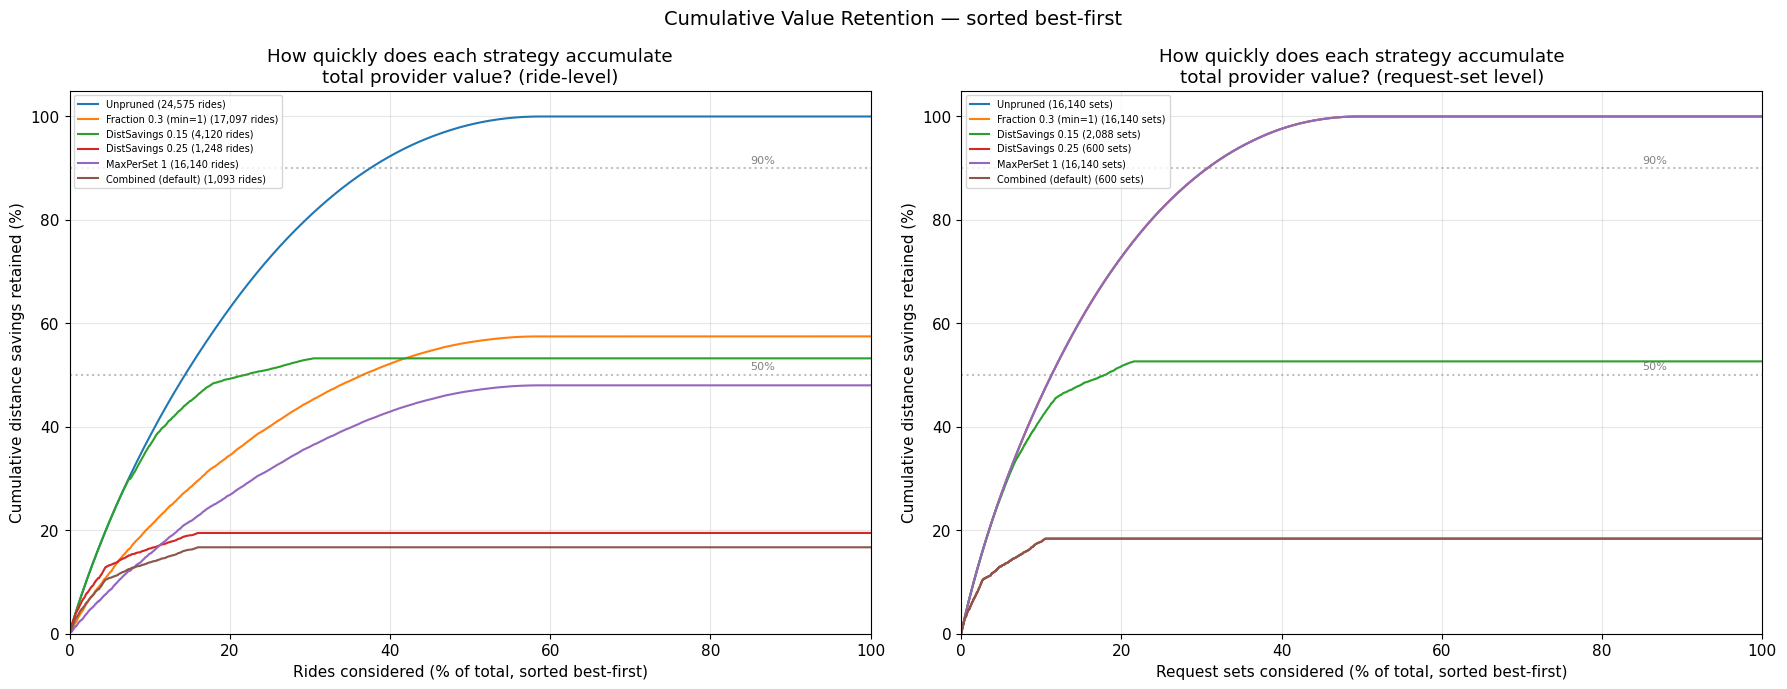

=== Rides/Sets needed to capture 90% of total savings ===
Strategy                         Rides for 90%    Sets for 90%
-----------------------------------------------------------------
Unpruned                        9,223 (37.5%)  4,959 (30.7%)
Fraction 0.3 (min=1)           24,575 (100.0%)  4,959 (30.7%)
DistSavings 0.15               24,575 (100.0%) 16,140 (100.0%)
DistSavings 0.25               24,575 (100.0%) 16,140 (100.0%)
MaxPerSet 1                    24,575 (100.0%)  4,959 (30.7%)
Combined (default)             24,575 (100.0%) 16,140 (100.0%)


In [87]:
# --- Metric 4d: Cumulative Value Retained ---
# Sort ALL rides by distance savings (best first). Walk down the ranked list
# and track: what fraction of cumulative savings value does each strategy retain?
# This shows how well pruning preserves the "upper end" while cutting the rest.

# Sort all pooled rides by savings descending
ranked = pooled.sort_values('distanceSavings', ascending=False).copy()
ranked['cumSavings'] = ranked['distanceSavings'].clip(lower=0).cumsum()
total_positive_savings = ranked['distanceSavings'].clip(lower=0).sum()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Plot 1: Global ride-level ---
ax = axes[0]
subset_strats = ['Unpruned', 'Fraction 0.3 (min=1)', 'DistSavings 0.15', 
                 'DistSavings 0.25', 'MaxPerSet 1', 'Combined (default)']

for name in subset_strats:
    df = results[name]
    kept_indices = set(df['rideIndex'])
    # Walk the globally-ranked list, accumulate savings only for surviving rides
    cum = 0
    xs = []  # ride rank (as fraction of total)
    ys = []  # cumulative savings retained (as fraction of total)
    for idx, row in ranked.iterrows():
        if row['rideIndex'] in kept_indices:
            cum += max(0, row['distanceSavings'])
        xs.append(len(xs) / len(ranked))
        ys.append(cum / total_positive_savings * 100)
    ax.plot([x * 100 for x in xs], ys, label=f'{name} ({len(df):,} rides)')

ax.set_xlabel('Rides considered (% of total, sorted best-first)')
ax.set_ylabel('Cumulative distance savings retained (%)')
ax.set_title('How quickly does each strategy accumulate\ntotal provider value? (ride-level)')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 100)
ax.set_ylim(0, 105)
# Add reference lines
ax.axhline(y=90, color='grey', linestyle=':', alpha=0.5)
ax.axhline(y=50, color='grey', linestyle=':', alpha=0.5)
ax.text(85, 91, '90%', fontsize=8, color='grey')
ax.text(85, 51, '50%', fontsize=8, color='grey')

# --- Plot 2: Request-set level ---
ax = axes[1]

# Best ride per set, ranked by savings
best_per_set = pooled.loc[pooled.groupby('requestSetKey')['distanceSavings'].idxmax()]
best_ranked = best_per_set.sort_values('distanceSavings', ascending=False).copy()
total_set_savings = best_ranked['distanceSavings'].clip(lower=0).sum()

for name in subset_strats:
    df = results[name]
    pruned_sets = set(df['requestSetKey'].unique())
    # For surviving sets, use their best ride's savings from the pruned dataset
    pruned_best = df.loc[df.groupby('requestSetKey')['distanceSavings'].idxmax()]
    pruned_best_dict = pruned_best.set_index('requestSetKey')['distanceSavings'].to_dict()
    
    cum = 0
    xs = []
    ys = []
    for idx, row in best_ranked.iterrows():
        key = row['requestSetKey']
        if key in pruned_sets:
            cum += max(0, pruned_best_dict.get(key, 0))
        xs.append(len(xs) / len(best_ranked))
        ys.append(cum / total_set_savings * 100)
    ax.plot([x * 100 for x in xs], ys, label=f'{name} ({df["requestSetKey"].nunique():,} sets)')

ax.set_xlabel('Request sets considered (% of total, sorted best-first)')
ax.set_ylabel('Cumulative distance savings retained (%)')
ax.set_title('How quickly does each strategy accumulate\ntotal provider value? (request-set level)')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 100)
ax.set_ylim(0, 105)
ax.axhline(y=90, color='grey', linestyle=':', alpha=0.5)
ax.axhline(y=50, color='grey', linestyle=':', alpha=0.5)
ax.text(85, 91, '90%', fontsize=8, color='grey')
ax.text(85, 51, '50%', fontsize=8, color='grey')

plt.suptitle('Cumulative Value Retention — sorted best-first', fontsize=14)
plt.tight_layout()
plt.savefig(str(BASE / 'pruning_cumulative_value.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print: at what % of rides/sets does each strategy reach 90% of total value?
print('=== Rides/Sets needed to capture 90% of total savings ===')
print(f'{"Strategy":30s} {"Rides for 90%":>15s} {"Sets for 90%":>15s}')
print('-' * 65)
for name in subset_strats:
    df = results[name]
    kept_indices = set(df['rideIndex'])
    pruned_sets = set(df['requestSetKey'].unique())
    
    # Ride-level
    cum = 0
    ride_90 = len(ranked)
    for i, (idx, row) in enumerate(ranked.iterrows()):
        if row['rideIndex'] in kept_indices:
            cum += max(0, row['distanceSavings'])
        if cum >= total_positive_savings * 0.9:
            ride_90 = i + 1
            break
    
    # Set-level  
    pruned_best = df.loc[df.groupby('requestSetKey')['distanceSavings'].idxmax()]
    pruned_best_dict = pruned_best.set_index('requestSetKey')['distanceSavings'].to_dict()
    cum = 0
    set_90 = len(best_ranked)
    for i, (idx, row) in enumerate(best_ranked.iterrows()):
        key = row['requestSetKey']
        if key in pruned_sets:
            cum += max(0, pruned_best_dict.get(key, 0))
        if cum >= total_set_savings * 0.9:
            set_90 = i + 1
            break
    
    r_pct = ride_90 / len(ranked) * 100
    s_pct = set_90 / len(best_ranked) * 100
    print(f'{name:30s} {ride_90:>6,} ({r_pct:>4.1f}%) {set_90:>6,} ({s_pct:>4.1f}%)')

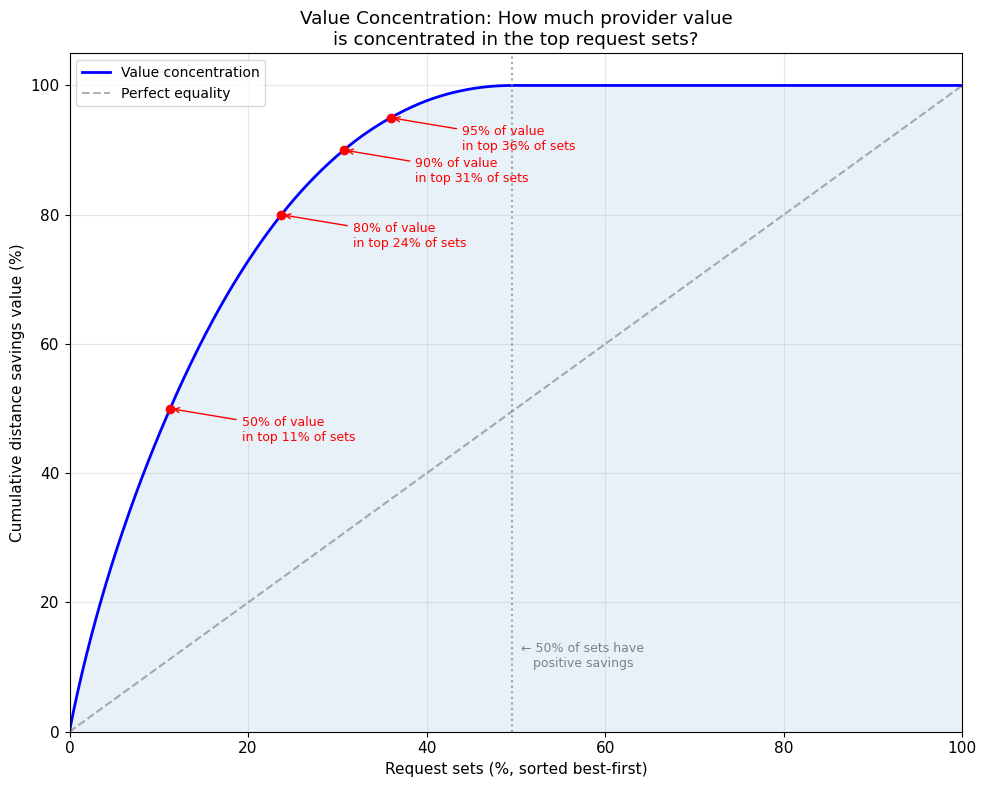

=== Value Concentration ===
  Top 11.3% of sets → 50% of total savings value
  Top 23.7% of sets → 80% of total savings value
  Top 30.7% of sets → 90% of total savings value
  Top 36.0% of sets → 95% of total savings value
  Top 43.3% of sets → 99% of total savings value
  49.6% of sets have positive savings (rest are harmful)
  Total request sets: 16,140


In [88]:
# --- Metric 5: Value Concentration (Lorenz Curve) ---
# Shows how concentrated provider value is across request sets.
# If 20% of sets hold 80% of value, pruning the bottom 80% is nearly free.

best_per_set = pooled.loc[pooled.groupby('requestSetKey')['distanceSavings'].idxmax()].copy()
best_per_set_sorted = best_per_set.sort_values('distanceSavings', ascending=False)

# Only count positive savings (negative sets have no provider value)
positive_savings = best_per_set_sorted['distanceSavings'].clip(lower=0).values
total_val = positive_savings.sum()

# Cumulative: walking from best to worst
cum_val = np.cumsum(positive_savings) / total_val * 100
cum_sets = np.arange(1, len(positive_savings) + 1) / len(positive_savings) * 100

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(cum_sets, cum_val, 'b-', linewidth=2, label='Value concentration')
ax.plot([0, 100], [0, 100], 'k--', alpha=0.3, label='Perfect equality')
ax.fill_between(cum_sets, cum_val, alpha=0.1)

# Annotate key points
for target_val in [50, 80, 90, 95]:
    idx = np.searchsorted(cum_val, target_val)
    if idx < len(cum_sets):
        pct_sets = cum_sets[idx]
        ax.plot(pct_sets, target_val, 'ro', markersize=6)
        ax.annotate(f'{target_val}% of value\nin top {pct_sets:.0f}% of sets',
                    xy=(pct_sets, target_val), xytext=(pct_sets + 8, target_val - 5),
                    fontsize=9, arrowprops=dict(arrowstyle='->', color='red'),
                    color='red')

# Mark where savings go negative
n_positive = (best_per_set_sorted['distanceSavings'] > 0).sum()
pct_positive = n_positive / len(best_per_set_sorted) * 100
ax.axvline(x=pct_positive, color='grey', linestyle=':', alpha=0.7)
ax.text(pct_positive + 1, 10, f'← {pct_positive:.0f}% of sets have\n   positive savings', 
        fontsize=9, color='grey')

ax.set_xlabel('Request sets (%, sorted best-first)')
ax.set_ylabel('Cumulative distance savings value (%)')
ax.set_title('Value Concentration: How much provider value\nis concentrated in the top request sets?')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 100)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(str(BASE / 'pruning_lorenz_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print key numbers
print('=== Value Concentration ===')
for target in [50, 80, 90, 95, 99]:
    idx = np.searchsorted(cum_val, target)
    if idx < len(cum_sets):
        print(f'  Top {cum_sets[idx]:4.1f}% of sets → {target}% of total savings value')
print(f'  {pct_positive:.1f}% of sets have positive savings (rest are harmful)')
print(f'  Total request sets: {len(best_per_set_sorted):,}')

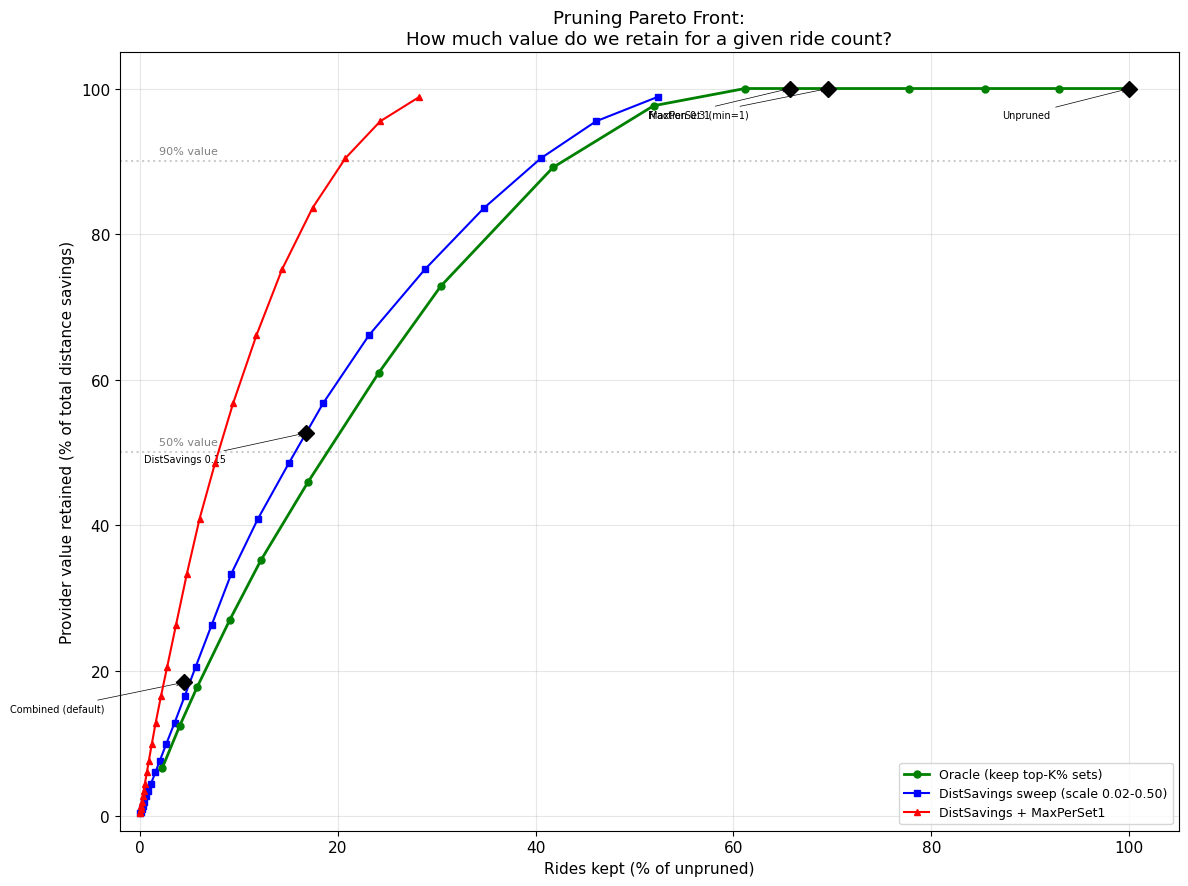

=== Pruning Pareto Front (Oracle) ===
 Sets kept %  Rides kept %  Value retained %    Sets
-------------------------------------------------------
          1%          2.3%              6.7%     161
          2%          4.1%             12.4%     322
          3%          5.8%             17.7%     484
          5%          9.1%             27.0%     807
          7%         12.2%             35.1%   1,129
         10%         17.0%             45.9%   1,614
         15%         24.1%             60.9%   2,421
         20%         30.4%             72.8%   3,228
         30%         41.8%             89.2%   4,842
         40%         51.9%             97.6%   6,456
         50%         61.2%            100.0%   8,070
         60%         69.7%            100.0%   9,684
         70%         77.7%            100.0%  11,298
         80%         85.4%            100.0%  12,912
         90%         92.9%            100.0%  14,526
        100%        100.0%            100.0%  16,140

=== 

In [89]:
# --- Metric 6: Pruning Pareto Front ---
# Sweep over many parameter values and oracle strategies.
# Plot: x = % rides kept, y = % value retained.
# The efficient frontier shows the best achievable tradeoff.

def eval_strategy(pruned_df, baseline_pooled):
    """Compute rides kept % and value retained % for a pruned dataset."""
    rides_kept_pct = len(pruned_df) / len(baseline_pooled) * 100
    
    pruned_best = pruned_df.loc[pruned_df.groupby('requestSetKey')['distanceSavings'].idxmax()]
    baseline_best = baseline_pooled.loc[baseline_pooled.groupby('requestSetKey')['distanceSavings'].idxmax()]
    
    val_retained = pruned_best['distanceSavings'].clip(lower=0).sum()
    val_total = baseline_best['distanceSavings'].clip(lower=0).sum()
    val_retained_pct = val_retained / val_total * 100
    
    sets_kept = pruned_df['requestSetKey'].nunique()
    
    return rides_kept_pct, val_retained_pct, sets_kept

# --- Oracle: keep top K% of request sets by best savings ---
oracle_points = []
best_per_set = pooled.loc[pooled.groupby('requestSetKey')['distanceSavings'].idxmax()].copy()
best_per_set_sorted = best_per_set.sort_values('distanceSavings', ascending=False)
all_set_keys = best_per_set_sorted['requestSetKey'].values

for keep_pct in [1, 2, 3, 5, 7, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100]:
    n_keep = max(1, int(len(all_set_keys) * keep_pct / 100))
    kept_keys = set(all_set_keys[:n_keep])
    oracle_pruned = pooled[pooled['requestSetKey'].isin(kept_keys)]
    rk, vr, sk = eval_strategy(oracle_pruned, pooled)
    oracle_points.append((rk, vr, f'Oracle top-{keep_pct}%', sk))

# --- DistSavings sweep ---
dist_points = []
for scale in np.arange(0.02, 0.52, 0.02):
    pruned = prune_distance_savings(pooled, scale)
    if len(pruned) > 0:
        rk, vr, sk = eval_strategy(pruned, pooled)
        dist_points.append((rk, vr, f'DS {scale:.2f}', sk))

# --- Combined sweep: DistSavings + MaxPerSet 1 ---
combined_points = []
for scale in np.arange(0.02, 0.52, 0.02):
    pruned = prune_distance_savings(pooled, scale)
    pruned = prune_max_per_set(pruned, 1) if len(pruned) > 0 else pruned
    if len(pruned) > 0:
        rk, vr, sk = eval_strategy(pruned, pooled)
        combined_points.append((rk, vr, f'DS{scale:.2f}+Max1', sk))

# --- Named strategies ---
named_points = []
for name, df in results.items():
    rk, vr, sk = eval_strategy(df, pooled)
    named_points.append((rk, vr, name, sk))

# Plot
fig, ax = plt.subplots(figsize=(12, 9))

# Oracle frontier (line)
ox = [p[0] for p in oracle_points]
oy = [p[1] for p in oracle_points]
ax.plot(ox, oy, 'g-o', linewidth=2, markersize=5, label='Oracle (keep top-K% sets)', zorder=5)

# DistSavings sweep
dx = [p[0] for p in dist_points]
dy = [p[1] for p in dist_points]
ax.plot(dx, dy, 'b-s', linewidth=1.5, markersize=4, label='DistSavings sweep (scale 0.02-0.50)', zorder=4)

# Combined sweep
cx = [p[0] for p in combined_points]
cy = [p[1] for p in combined_points]
ax.plot(cx, cy, 'r-^', linewidth=1.5, markersize=4, label='DistSavings + MaxPerSet1', zorder=4)

# Named strategies as labeled points
for rk, vr, name, sk in named_points:
    if name in ['Unpruned', 'Fraction 0.3 (min=1)', 'MaxPerSet 1', 'DistSavings 0.15', 'Combined (default)']:
        ax.plot(rk, vr, 'kD', markersize=8, zorder=6)
        ax.annotate(name, xy=(rk, vr), xytext=(rk - 8, vr - 4),
                    fontsize=7, ha='right',
                    arrowprops=dict(arrowstyle='->', color='black', lw=0.5))

ax.set_xlabel('Rides kept (% of unpruned)')
ax.set_ylabel('Provider value retained (% of total distance savings)')
ax.set_title('Pruning Pareto Front:\nHow much value do we retain for a given ride count?')
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim(-2, 105)
ax.set_ylim(-2, 105)

# Reference lines
ax.axhline(y=90, color='grey', linestyle=':', alpha=0.4)
ax.axhline(y=50, color='grey', linestyle=':', alpha=0.4)
ax.text(2, 91, '90% value', fontsize=8, color='grey')
ax.text(2, 51, '50% value', fontsize=8, color='grey')

plt.tight_layout()
plt.savefig(str(BASE / 'pruning_pareto_front.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print the frontier
print('=== Pruning Pareto Front (Oracle) ===')
print(f'{"Sets kept %":>12s} {"Rides kept %":>13s} {"Value retained %":>17s} {"Sets":>7s}')
print('-' * 55)
for rk, vr, name, sk in oracle_points:
    keep_pct = name.split('-')[1].rstrip('%')
    print(f'{keep_pct:>11s}% {rk:>12.1f}% {vr:>16.1f}% {sk:>7,}')

print()
print('=== DistSavings Sweep (key points) ===')
print(f'{"Scale":>6s} {"Rides kept %":>13s} {"Value retained %":>17s} {"Sets":>7s}')
print('-' * 48)
for rk, vr, name, sk in dist_points:
    scale = float(name.split()[1])
    if scale in [0.04, 0.08, 0.10, 0.12, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]:
        print(f'{scale:>6.2f} {rk:>12.1f}% {vr:>16.1f}% {sk:>7,}')

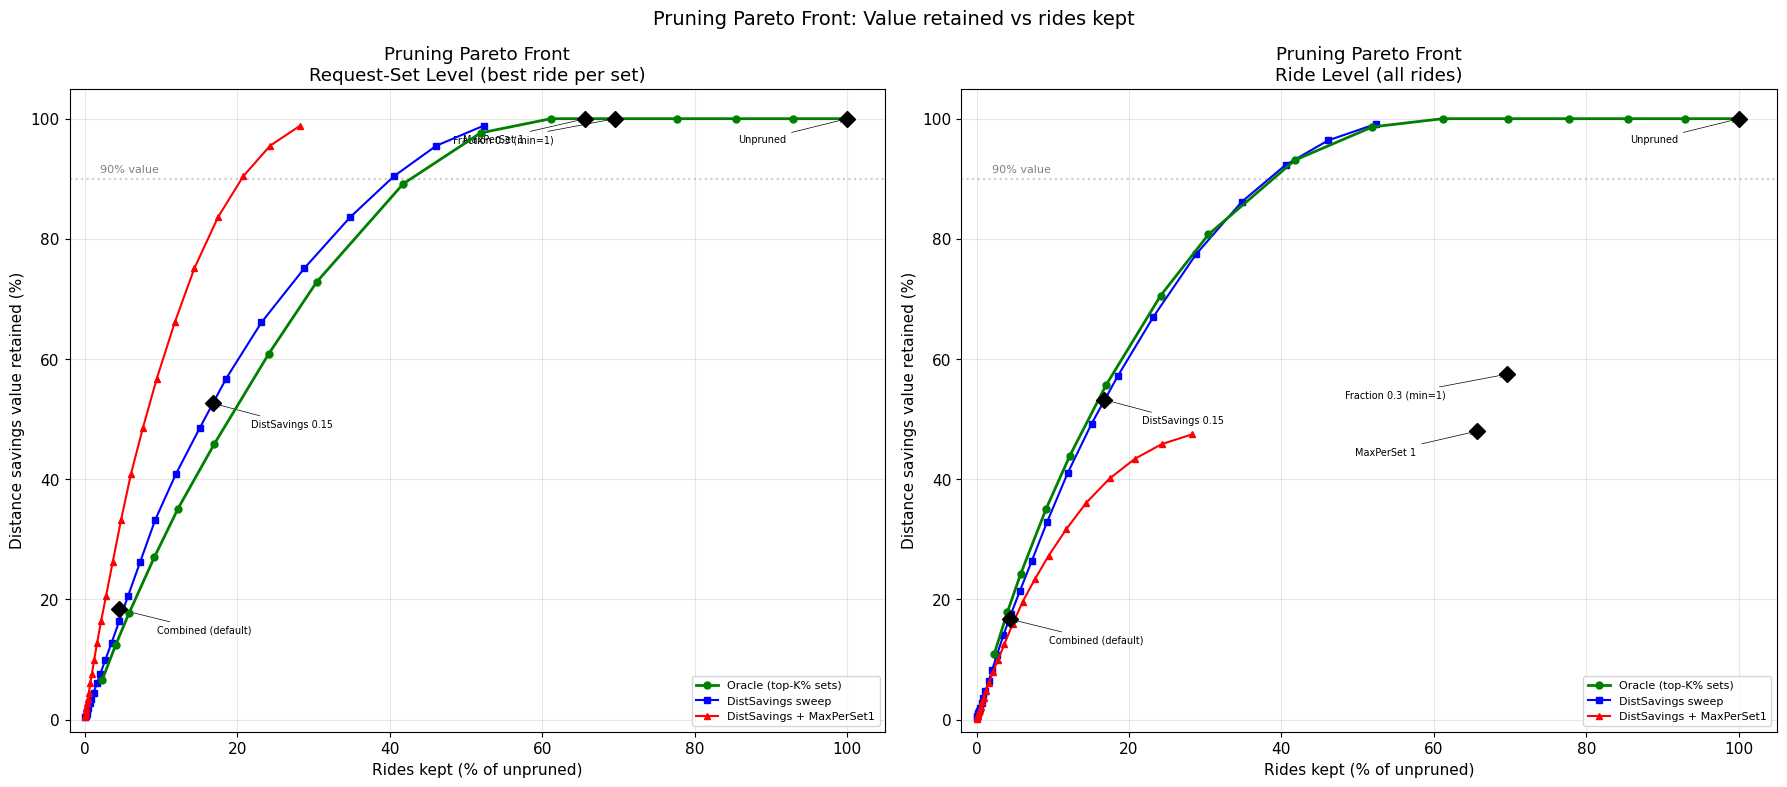

In [90]:
# --- Metric 6b: Pareto Front — Ride Level ---
# Same as above but measuring value as sum of savings across ALL surviving rides,
# not just the best per set. This captures variant retention too.

def eval_strategy_ride_level(pruned_df, baseline_pooled):
    """Ride-level: total savings across all kept rides."""
    rides_kept_pct = len(pruned_df) / len(baseline_pooled) * 100
    val_retained = pruned_df['distanceSavings'].clip(lower=0).sum()
    val_total = baseline_pooled['distanceSavings'].clip(lower=0).sum()
    val_retained_pct = val_retained / val_total * 100
    return rides_kept_pct, val_retained_pct

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax_idx, (eval_fn, level_name) in enumerate([
    (eval_strategy, 'Request-Set Level (best ride per set)'),
    (eval_strategy_ride_level, 'Ride Level (all rides)')
]):
    ax = axes[ax_idx]
    
    # Oracle
    ox, oy = [], []
    for keep_pct in [1, 2, 3, 5, 7, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100]:
        n_keep = max(1, int(len(all_set_keys) * keep_pct / 100))
        kept_keys = set(all_set_keys[:n_keep])
        oracle_pruned = pooled[pooled['requestSetKey'].isin(kept_keys)]
        rk, vr = eval_fn(oracle_pruned, pooled)[:2]
        ox.append(rk); oy.append(vr)
    ax.plot(ox, oy, 'g-o', linewidth=2, markersize=5, label='Oracle (top-K% sets)', zorder=5)
    
    # DistSavings sweep
    dsx, dsy = [], []
    for scale in np.arange(0.02, 0.52, 0.02):
        pruned = prune_distance_savings(pooled, scale)
        if len(pruned) > 0:
            rk, vr = eval_fn(pruned, pooled)[:2]
            dsx.append(rk); dsy.append(vr)
    ax.plot(dsx, dsy, 'b-s', linewidth=1.5, markersize=4, label='DistSavings sweep', zorder=4)
    
    # Combined: DistSavings + MaxPerSet 1
    csx, csy = [], []
    for scale in np.arange(0.02, 0.52, 0.02):
        pruned = prune_distance_savings(pooled, scale)
        pruned = prune_max_per_set(pruned, 1) if len(pruned) > 0 else pruned
        if len(pruned) > 0:
            rk, vr = eval_fn(pruned, pooled)[:2]
            csx.append(rk); csy.append(vr)
    ax.plot(csx, csy, 'r-^', linewidth=1.5, markersize=4, label='DistSavings + MaxPerSet1', zorder=4)
    
    # Named strategies
    for name, df in results.items():
        if name in ['Unpruned', 'Fraction 0.3 (min=1)', 'MaxPerSet 1', 'DistSavings 0.15', 'Combined (default)']:
            rk, vr = eval_fn(df, pooled)[:2]
            ax.plot(rk, vr, 'kD', markersize=8, zorder=6)
            offset = (-8, -4) if rk > 20 else (5, -4)
            ha = 'right' if rk > 20 else 'left'
            ax.annotate(name, xy=(rk, vr), xytext=(rk + offset[0], vr + offset[1]),
                        fontsize=7, ha=ha,
                        arrowprops=dict(arrowstyle='->', color='black', lw=0.5))
    
    ax.set_xlabel('Rides kept (% of unpruned)')
    ax.set_ylabel('Distance savings value retained (%)')
    ax.set_title(f'Pruning Pareto Front\n{level_name}')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-2, 105)
    ax.set_ylim(-2, 105)
    ax.axhline(y=90, color='grey', linestyle=':', alpha=0.4)
    ax.text(2, 91, '90% value', fontsize=8, color='grey')

plt.suptitle('Pruning Pareto Front: Value retained vs rides kept', fontsize=14)
plt.tight_layout()
plt.savefig(str(BASE / 'pruning_pareto_both_levels.png'), dpi=150, bbox_inches='tight')
plt.show()

C:\Users\VWAUCCY\AppData\Local\Temp\ipykernel_41320\2096151800.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


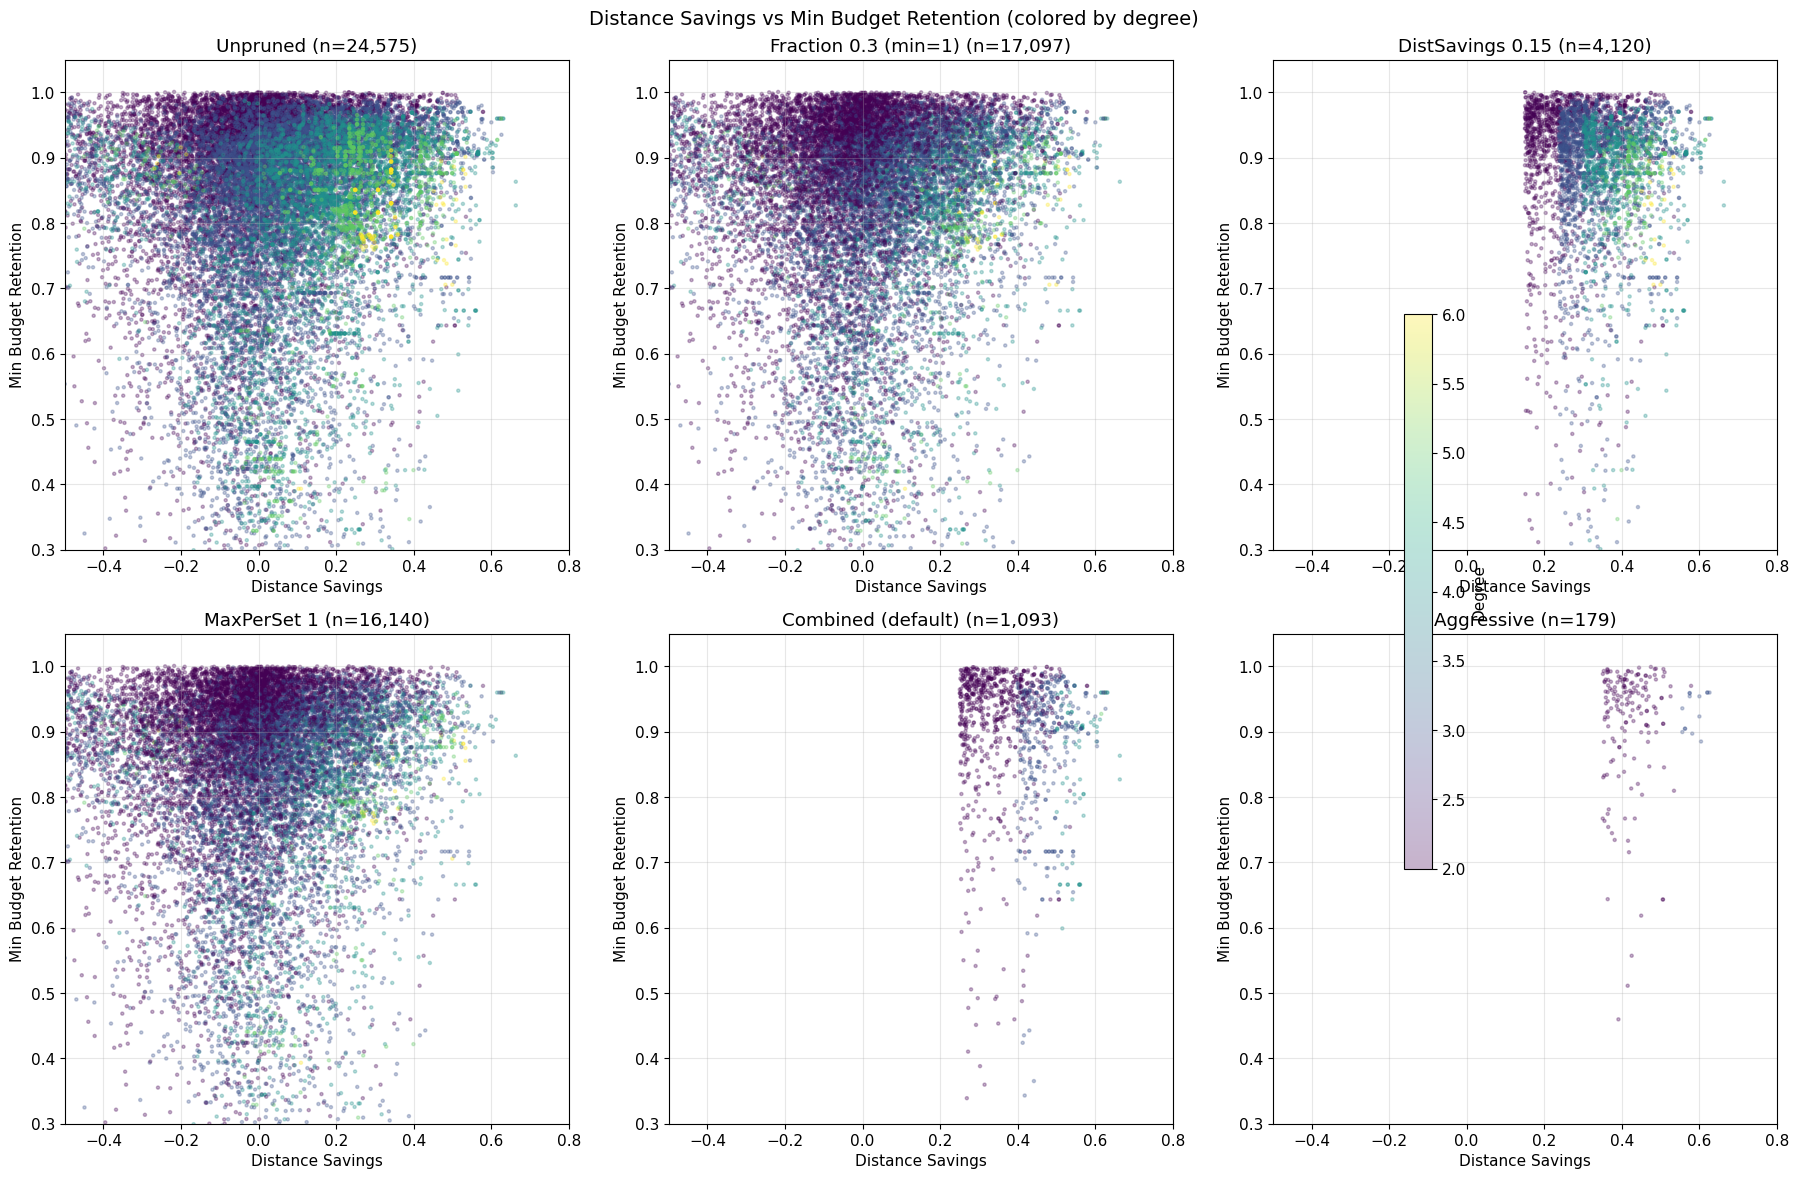

In [91]:
# --- Metric 5: 2D Scatter - Distance Savings vs Min Budget Retention ---

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
scatter_strategies = ['Unpruned', 'Fraction 0.3 (min=1)', 'DistSavings 0.15',
                      'MaxPerSet 1', 'Combined (default)', 'Aggressive']

for ax, name in zip(axes.flat, scatter_strategies):
    df = results[name]
    df_valid = df.dropna(subset=['distanceSavings', 'minBudgetRetention'])
    scatter = ax.scatter(
        df_valid['distanceSavings'], df_valid['minBudgetRetention'],
        c=df_valid['degree'], cmap='viridis', alpha=0.3, s=5,
        vmin=2, vmax=pooled['degree'].max())
    ax.set_xlabel('Distance Savings')
    ax.set_ylabel('Min Budget Retention')
    ax.set_title(f'{name} (n={len(df_valid):,})')
    ax.set_xlim(-0.5, 0.8)
    ax.set_ylim(0.3, 1.05)
    ax.grid(True, alpha=0.3)

plt.colorbar(scatter, ax=axes, label='Degree', shrink=0.6)
plt.suptitle('Distance Savings vs Min Budget Retention (colored by degree)', fontsize=14)
plt.tight_layout()
plt.savefig(str(BASE / 'pruning_comparison_scatter.png'), dpi=150)
plt.show()

In [92]:
# --- Summary Table ---

summary = []
for name, df in results.items():
    best_savings = best_metric_per_request(df, 'distanceSavings', 'max')
    best_min_budget = best_metric_per_request(df, 'minBudgetRetention', 'max').dropna()
    reach = pooling_reach_per_request(df)
    surv_savings = best_ride_per_set_survival(pooled, df, 'distanceSavings')
    surv_budget = best_ride_per_set_survival(pooled, df, 'minBudgetRetention')
    n_sets = df['requestSetKey'].nunique()
    n_reqs = request_coverage(df)
    
    summary.append({
        'Strategy': name,
        'Rides': len(df),
        'Sets': n_sets,
        'Reqs': n_reqs,
        'Reduction %': (1 - len(df) / len(pooled)) * 100,
        'Med Best Savings': best_savings.median(),
        'Med Best MinBudRet': best_min_budget.median() if len(best_min_budget) > 0 else np.nan,
        'Med Reach': reach.median(),
        'Set Surv 5% (sav)': surv_savings['top-5%'],
        'Set Surv 5% (bud)': surv_budget['top-5%'],
    })

summary_df = pd.DataFrame(summary)
summary_df = summary_df.set_index('Strategy')
print(summary_df.to_string(float_format=lambda x: f'{x:.3f}'))

                      Rides   Sets  Reqs  Reduction %  Med Best Savings  Med Best MinBudRet  Med Reach  Set Surv 5% (sav)  Set Surv 5% (bud)
Strategy                                                                                                                                    
Unpruned              24575  16140  1787        0.000             0.141               0.976      5.000              1.000              1.000
Fraction 0.3 (min=3)  22894  16140  1787        6.840             0.141               0.976      5.000              1.000              1.000
Fraction 0.5 (min=3)  23071  16140  1787        6.120             0.141               0.976      5.000              1.000              1.000
Fraction 0.3 (min=1)  17097  16140  1787       30.429             0.141               0.974      5.000              1.000              1.000
DistSavings 0.15       4120   2088   822       83.235             0.323               0.960      3.000              0.985              0.200
DistSavings 0

In [ ]:
# === FIGURE: Key Takeaway — Two-Panel Summary ===
#
# Panel A (left): Scatter of ALL rides — kept vs pruned, showing quality filtering
# Panel B (right): Pareto front — database size vs value retained
#
# Strategy: DistSavings + MaxPerSet=1 with cascading per degree

# --- Step 1: Simulate cascading DistSavings + MaxPerSet=1 ---

def cascading_dist_savings_max1(df, scale, max_saving=0.75):
    """Cascade: at each degree, gate by savings, keep max 1 per set, 
    then only allow next-degree rides whose bases survived."""
    surviving_sets = {}
    kept_indices = set()
    
    for d in sorted(df['degree'].unique()):
        sub = df[df['degree'] == d].copy()
        
        # Gate 1: cascade — ride's bases must have survived at d-1
        if d >= 3:
            valid_idx = []
            for idx, row in sub.iterrows():
                req_set = row['requestSetKey']
                has_base = False
                for excluded in req_set:
                    subset = tuple(r for r in req_set if r != excluded)
                    if subset in surviving_sets.get(d - 1, set()):
                        has_base = True
                        break
                if has_base:
                    valid_idx.append(idx)
            sub = sub.loc[valid_idx] if valid_idx else sub.iloc[0:0]
        
        # Gate 2: distance-savings threshold
        req_sav = min(scale * np.log2(max(d, 2)), max_saving)
        sub = sub[sub['distanceSavings'] >= req_sav]
        
        # Gate 3: keep best 1 per request set
        if len(sub) > 0:
            best = sub.loc[sub.groupby('requestSetKey')['rideDistance'].idxmin()]
            for rid in best['rideIndex']:
                kept_indices.add(rid)
            if d not in surviving_sets:
                surviving_sets[d] = set()
            for key in best['requestSetKey']:
                surviving_sets[d].add(key)
    
    return df[df['rideIndex'].isin(kept_indices)]

# Need requestSetKey as tuple for subset checks
pooled['requestSetKey_tuple'] = pooled['_requestIndices'].apply(lambda x: tuple(sorted(x)))
# Temporarily swap for the cascade function
_orig_key = pooled['requestSetKey'].copy()
pooled['requestSetKey'] = pooled['requestSetKey_tuple']

# Sweep scales
sweep_results = []
for scale in np.arange(0.00, 0.32, 0.01):
    pruned = cascading_dist_savings_max1(pooled, scale)
    if len(pruned) == 0:
        continue
    rides_pct = len(pruned) / len(pooled) * 100
    pruned_best = pruned.loc[pruned.groupby('requestSetKey')['distanceSavings'].idxmax()]
    baseline_best = pooled.loc[pooled.groupby('requestSetKey')['distanceSavings'].idxmax()]
    val_pct = pruned_best['distanceSavings'].clip(lower=0).sum() / baseline_best['distanceSavings'].clip(lower=0).sum() * 100
    n_sets = pruned['requestSetKey'].nunique()
    sweep_results.append({
        'scale': scale, 'rides_pct': rides_pct, 'val_pct': val_pct,
        'n_rides': len(pruned), 'n_sets': n_sets
    })
sweep_df = pd.DataFrame(sweep_results)

# Pick showcase scale
showcase_scale = 0.06
showcase = cascading_dist_savings_max1(pooled, showcase_scale)
kept_ids = set(showcase['rideIndex'])
pooled['kept'] = pooled['rideIndex'].isin(kept_ids)

sc_row = sweep_df[sweep_df['scale'] == showcase_scale].iloc[0]
print(f'Showcase: scale={showcase_scale}, rides={sc_row["n_rides"]:.0f} ({sc_row["rides_pct"]:.1f}%), '
      f'value={sc_row["val_pct"]:.1f}%, sets={sc_row["n_sets"]:.0f}')


# === THE PLOT ===
fig = plt.figure(figsize=(18, 8))
gs = fig.add_gridspec(1, 2, width_ratios=[1.1, 1], wspace=0.25)

# --- Panel A: Scatter — kept (green) vs pruned (red) ---
ax_a = fig.add_subplot(gs[0])

pruned_mask = ~pooled['kept']
ax_a.scatter(
    pooled.loc[pruned_mask, 'distanceSavings'],
    pooled.loc[pruned_mask, 'degree'] + np.random.uniform(-0.25, 0.25, pruned_mask.sum()),
    c='#d62728', alpha=0.12, s=6, label=f'Pruned ({pruned_mask.sum():,} rides)', zorder=2,
    rasterized=True)

kept_mask = pooled['kept']
ax_a.scatter(
    pooled.loc[kept_mask, 'distanceSavings'],
    pooled.loc[kept_mask, 'degree'] + np.random.uniform(-0.25, 0.25, kept_mask.sum()),
    c='#2ca02c', alpha=0.35, s=10, label=f'Kept ({kept_mask.sum():,} rides)', zorder=3,
    rasterized=True)

ax_a.axvline(x=0, color='black', linestyle='-', alpha=0.3, linewidth=1)

# Degree-specific thresholds
for d in sorted(pooled['degree'].unique()):
    thresh = min(showcase_scale * np.log2(max(d, 2)), 0.75)
    ax_a.plot([thresh, thresh], [d - 0.4, d + 0.4], color='black', linewidth=2.5, zorder=4)

ax_a.set_xlabel('Distance Savings\n(negative = pooling adds distance, positive = pooling saves vehicle-km)', fontsize=11)
ax_a.set_ylabel('Pooling Degree (passengers per ride)', fontsize=11)
ax_a.set_yticks(sorted(pooled['degree'].unique()))
ax_a.set_title(f'Quality Filtering: kept rides (green) vs pruned rides (red)\n'
               f'DistSavings scale={showcase_scale} + MaxPerSet=1, cascading per degree', fontsize=12)
ax_a.legend(fontsize=10, loc='upper left')
ax_a.grid(True, alpha=0.2, axis='x')
ax_a.set_xlim(-0.8, 0.75)

ax_a.annotate('Threshold increases\nwith degree', xy=(0.22, 4.5), fontsize=9,
              fontstyle='italic', color='black', ha='center',
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='grey', alpha=0.8))

# --- Panel B: Pareto front — reduction vs value ---
ax_b = fig.add_subplot(gs[1])

# Oracle frontier
ox, oy = [], []
best_per_set = pooled.loc[pooled.groupby('requestSetKey')['distanceSavings'].idxmax()].copy()
best_per_set_sorted = best_per_set.sort_values('distanceSavings', ascending=False)
all_set_keys = best_per_set_sorted['requestSetKey'].values
baseline_val = best_per_set_sorted['distanceSavings'].clip(lower=0).sum()

for keep_pct in [1, 2, 3, 5, 7, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100]:
    n_keep = max(1, int(len(all_set_keys) * keep_pct / 100))
    kept_keys = set(all_set_keys[:n_keep])
    oracle_pruned = pooled[pooled['requestSetKey'].isin(kept_keys)]
    rk = len(oracle_pruned) / len(pooled) * 100
    oracle_best = oracle_pruned.loc[oracle_pruned.groupby('requestSetKey')['distanceSavings'].idxmax()]
    vr = oracle_best['distanceSavings'].clip(lower=0).sum() / baseline_val * 100
    ox.append(100 - rk); oy.append(vr)

ax_b.plot(ox, oy, 'k--', linewidth=1.5, alpha=0.5, label='Oracle (theoretical best)', zorder=3)
ax_b.fill_between(ox, oy, 100, alpha=0.05, color='green')

# Our cascading strategy sweep
sx = 100 - sweep_df['rides_pct']
sy = sweep_df['val_pct']
ax_b.plot(sx, sy, 'b-o', linewidth=2.5, markersize=4, label='DistSavings + Max1 (cascading)', zorder=4)

# Highlight showcase point
sc_x = 100 - sc_row['rides_pct']
sc_y = sc_row['val_pct']
ax_b.plot(sc_x, sc_y, 'r*', markersize=18, zorder=5, 
          label=f'Scale={showcase_scale}: {100-sc_row["rides_pct"]:.0f}% reduction, {sc_row["val_pct"]:.0f}% value kept')

# Highlight other key points
for _, row in sweep_df.iterrows():
    if row['scale'] in [0.04, 0.10, 0.15, 0.20]:
        px = 100 - row['rides_pct']
        py = row['val_pct']
        ax_b.plot(px, py, 'bo', markersize=7, zorder=5)
        ax_b.annotate(f's={row["scale"]:.2f}\n{100-row["rides_pct"]:.0f}% red. → {row["val_pct"]:.0f}% val',
                      xy=(px, py), xytext=(px + 3, py - 6),
                      fontsize=7, color='blue')

ax_b.axhspan(90, 105, color='green', alpha=0.08)
ax_b.text(50, 101, '>90% value retained', fontsize=9, color='green', ha='center', fontstyle='italic')

ax_b.set_xlabel('Database size reduction (%)', fontsize=11)
ax_b.set_ylabel('Provider value retained\n(% of total distance savings)', fontsize=11)
ax_b.set_title('Pruning efficiency:\nHow much can we reduce while keeping value?', fontsize=12)
ax_b.legend(fontsize=9, loc='lower left')
ax_b.grid(True, alpha=0.3)
ax_b.set_xlim(-2, 100)
ax_b.set_ylim(-2, 105)

plt.suptitle('Pruning preserves high-quality pooling rides while heavily reducing database size',
             fontsize=14, fontweight='bold', y=1.02)
plt.savefig(str(BASE / 'pruning_key_takeaway.png'), dpi=200, bbox_inches='tight')
plt.show()

# Restore original requestSetKey and clean up
pooled['requestSetKey'] = _orig_key
pooled.drop(columns=['requestSetKey_tuple', 'kept'], inplace=True, errors='ignore')

# Summary stats
print(f'\n=== Key Takeaway Numbers ===')
print(f'Total pooled rides: {len(pooled):,}')
print(f'Request sets with negative savings: {(best_per_set["distanceSavings"] < 0).sum():,} '
      f'({(best_per_set["distanceSavings"] < 0).mean()*100:.0f}%)')
print(f'\nCascading DistSavings + MaxPerSet=1 sweep:')
for _, row in sweep_df.iterrows():
    if row['scale'] in [0.00, 0.04, 0.06, 0.08, 0.10, 0.15, 0.20]:
        print(f'  scale={row["scale"]:.2f}: {row["n_rides"]:.0f} rides ({row["rides_pct"]:.1f}%), '
              f'{row["n_sets"]:.0f} sets, {row["val_pct"]:.1f}% value retained')

In [ ]:
# === Per-Degree Pareto Front + P90 Elite Analysis ===

# Need tuple keys for cascade function
pooled['requestSetKey_tuple'] = pooled['_requestIndices'].apply(lambda x: tuple(sorted(x)))
_orig_key = pooled['requestSetKey'].copy()
pooled['requestSetKey'] = pooled['requestSetKey_tuple']

# Precompute P90 threshold per degree
p90_thresholds = {}
for d in sorted(pooled['degree'].unique()):
    sub = pooled[pooled['degree'] == d]
    p90_thresholds[d] = sub['distanceSavings'].quantile(0.90)
    
print('=== P90 savings threshold per degree ===')
for d, t in p90_thresholds.items():
    print(f'  Degree {d}: P90 = {t:+.3f} (top 10% of rides at this degree save more than {t*100:.1f}%)')

# --- Plot 1: Per-Degree Pareto Front ---
degrees = sorted(pooled['degree'].unique())
fig, axes = plt.subplots(1, len(degrees), figsize=(5 * len(degrees), 6), sharey=True)
if len(degrees) == 1:
    axes = [axes]

for ax, d in zip(axes, degrees):
    sub = pooled[pooled['degree'] == d]
    n_total = len(sub)
    
    # Baseline value at this degree
    best_per_set_d = sub.loc[sub.groupby('requestSetKey')['distanceSavings'].idxmax()]
    baseline_val_d = best_per_set_d['distanceSavings'].clip(lower=0).sum()
    all_set_keys_d = best_per_set_d.sort_values('distanceSavings', ascending=False)['requestSetKey'].values
    
    if baseline_val_d <= 0:
        ax.set_title(f'Degree {d}\n(no positive savings)')
        continue
    
    # Oracle for this degree
    ox, oy = [], []
    for keep_pct in [1, 3, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]:
        n_keep = max(1, int(len(all_set_keys_d) * keep_pct / 100))
        kept_keys = set(all_set_keys_d[:n_keep])
        oracle_sub = sub[sub['requestSetKey'].isin(kept_keys)]
        rk = len(oracle_sub) / n_total * 100
        ob = oracle_sub.loc[oracle_sub.groupby('requestSetKey')['distanceSavings'].idxmax()]
        vr = ob['distanceSavings'].clip(lower=0).sum() / baseline_val_d * 100
        ox.append(100 - rk); oy.append(vr)
    ax.plot(ox, oy, 'k--', linewidth=1.5, alpha=0.5, label='Oracle', zorder=3)
    
    # Cascading strategy sweep
    sx, sy = [], []
    for scale in np.arange(0.00, 0.32, 0.01):
        pruned_all = cascading_dist_savings_max1(pooled, scale)
        pruned_d = pruned_all[pruned_all['degree'] == d]
        if len(pruned_d) == 0:
            continue
        rk = len(pruned_d) / n_total * 100
        pb = pruned_d.loc[pruned_d.groupby('requestSetKey')['distanceSavings'].idxmax()]
        vr = pb['distanceSavings'].clip(lower=0).sum() / baseline_val_d * 100
        sx.append(100 - rk); sy.append(vr)
    ax.plot(sx, sy, 'b-o', linewidth=2, markersize=3, label='DS+Max1', zorder=4)
    
    ax.axhspan(90, 105, color='green', alpha=0.08)
    ax.set_xlabel('Reduction (%)')
    if d == degrees[0]:
        ax.set_ylabel('Value retained (%)')
    ax.set_title(f'Degree {d}\n({n_total:,} rides, P90={p90_thresholds[d]:+.2f})')
    ax.legend(fontsize=7, loc='lower left')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-2, 100)
    ax.set_ylim(-2, 105)

plt.suptitle('Per-Degree Pareto Front: Value retained vs database reduction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(BASE / 'pruning_pareto_per_degree.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 2: Same but only counting P90+ elite rides ---
fig, axes = plt.subplots(1, len(degrees), figsize=(5 * len(degrees), 6), sharey=True)
if len(degrees) == 1:
    axes = [axes]

for ax, d in zip(axes, degrees):
    sub = pooled[pooled['degree'] == d]
    p90 = p90_thresholds[d]
    elite = sub[sub['distanceSavings'] >= p90]
    n_elite = len(elite)
    
    if n_elite == 0:
        ax.set_title(f'Degree {d}\n(no P90+ rides)')
        continue
    
    # Elite sets and their value
    elite_best = elite.loc[elite.groupby('requestSetKey')['distanceSavings'].idxmax()]
    elite_set_keys = set(elite_best['requestSetKey'])
    elite_val = elite_best['distanceSavings'].clip(lower=0).sum()
    
    if elite_val <= 0:
        continue
    
    # For each pruning scale: how many elite sets survive?
    sx_rides, sy_val, sx_sets = [], [], []
    for scale in np.arange(0.00, 0.32, 0.01):
        pruned_all = cascading_dist_savings_max1(pooled, scale)
        pruned_d = pruned_all[pruned_all['degree'] == d]
        if len(pruned_d) == 0:
            sx_rides.append(100); sy_val.append(0); sx_sets.append(0)
            continue
        
        # How many elite sets survived?
        pruned_sets = set(pruned_d['requestSetKey'].unique())
        survived_elite = elite_set_keys & pruned_sets
        
        # Value from surviving elite sets (use their best ride in pruned set)
        if survived_elite:
            survived_best = pruned_d[pruned_d['requestSetKey'].isin(survived_elite)]
            survived_best = survived_best.loc[survived_best.groupby('requestSetKey')['distanceSavings'].idxmax()]
            val = survived_best['distanceSavings'].clip(lower=0).sum()
        else:
            val = 0
        
        total_reduction = (1 - len(pruned_d) / len(sub)) * 100
        sx_rides.append(total_reduction)
        sy_val.append(val / elite_val * 100)
        sx_sets.append(len(survived_elite) / len(elite_set_keys) * 100)
    
    ax.plot(sx_rides, sy_val, 'b-o', linewidth=2, markersize=3, label='Elite value retained', zorder=4)
    ax.plot(sx_rides, sx_sets, 'g--s', linewidth=1.5, markersize=3, label='Elite sets retained', zorder=3)
    
    ax.axhspan(90, 105, color='green', alpha=0.08)
    ax.set_xlabel('Total reduction at this degree (%)')
    if d == degrees[0]:
        ax.set_ylabel('P90+ elite retained (%)')
    ax.set_title(f'Degree {d}: Top 10% rides (P90≥{p90:+.2f})\n({n_elite:,} elite rides, {len(elite_set_keys):,} elite sets)')
    ax.legend(fontsize=7, loc='lower left')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-2, 100)
    ax.set_ylim(-2, 105)

plt.suptitle('Elite Ride Preservation: Do we keep the top 10% at each degree?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(BASE / 'pruning_elite_per_degree.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print('\n=== Elite (P90+) Survival at key pruning scales ===')
print(f'{"Scale":>6s}', end='')
for d in degrees:
    print(f'  d={d} elite%', end='')
print(f'  {"total rides%":>12s}')
print('-' * (6 + 12 * len(degrees) + 14))

for scale in [0.00, 0.04, 0.06, 0.08, 0.10, 0.15, 0.20]:
    pruned_all = cascading_dist_savings_max1(pooled, scale)
    row = f'{scale:>6.2f}'
    for d in degrees:
        sub_d = pooled[pooled['degree'] == d]
        p90 = p90_thresholds[d]
        elite = sub_d[sub_d['distanceSavings'] >= p90]
        elite_sets = set(elite.loc[elite.groupby('requestSetKey')['distanceSavings'].idxmax()]['requestSetKey'])
        
        pruned_d = pruned_all[pruned_all['degree'] == d]
        survived = elite_sets & set(pruned_d['requestSetKey'].unique()) if len(pruned_d) > 0 else set()
        pct = len(survived) / len(elite_sets) * 100 if elite_sets else 0
        row += f'  {pct:>10.0f}%'
    
    total_pct = len(pruned_all) / len(pooled) * 100
    row += f'  {total_pct:>11.1f}%'
    print(row)

# Restore
pooled['requestSetKey'] = _orig_key
pooled.drop(columns=['requestSetKey_tuple'], inplace=True, errors='ignore')

In [ ]:
# === KEY TAKEAWAY FIGURE (Correct Java cascade model) ===
#
# Java cascade: lenient — at each degree, a ride needs at least ONE (d-1)-subset
# that survived as a base. ALL degree-2 pair rides remain in rideMap/graph.
# getPairRides always finds pairs. Only extension BASES are affected by pruning.
#
# Panel A: Elite survival per degree vs pruning scale
# Panel B: Scatter showing kept vs pruned rides

from itertools import combinations

def java_cascade(df, scale, max_per_set=0, fraction=1.0, min_keep=1, max_saving=0.75):
    """Lenient cascade matching Java ExMasEngine behavior:
    - Degree 2: savings gate applied to BASES (allRides/rideMap keeps all pairs)
    - Degree 3+: ride needs at least ONE (d-1)-subset that survived as base
    - getPairRides always works (graph + rideMap have all pairs)"""
    surviving_sets = {}
    kept_indices = set()
    
    for d in sorted(df['degree'].unique()):
        sub = df[df['degree'] == d].copy()
        
        # Gate 1: savings threshold
        req_sav = min(scale * np.log2(max(d, 2)), max_saving)
        sub = sub[sub['distanceSavings'] >= req_sav]
        
        # Gate 2: cascade — at least one (d-1)-subset must have survived
        if d >= 3:
            valid_idx = []
            for idx, row in sub.iterrows():
                req_set = row['requestSetKey']
                has_base = any(
                    tuple(r for r in req_set if r != ex) in surviving_sets.get(d - 1, set())
                    for ex in req_set)
                if has_base:
                    valid_idx.append(idx)
            sub = sub.loc[valid_idx] if valid_idx else sub.iloc[0:0]
        
        # Gate 3: variant pruning (MaxPerSet / fraction)
        if len(sub) > 0 and (max_per_set > 0 or fraction < 1.0):
            kept_parts = []
            for key, group in sub.groupby('requestSetKey'):
                group_sorted = group.sort_values('rideDistance')
                n = len(group_sorted)
                keep = n
                if fraction < 1.0:
                    keep = max(int(np.ceil(n * fraction)), min_keep)
                if max_per_set > 0:
                    keep = min(keep, max_per_set)
                keep = min(keep, n)
                kept_parts.append(group_sorted.iloc[:keep])
            sub = pd.concat(kept_parts, ignore_index=True) if kept_parts else sub.iloc[0:0]
        
        if d not in surviving_sets:
            surviving_sets[d] = set()
        for _, row in sub.iterrows():
            kept_indices.add(row['rideIndex'])
            surviving_sets[d].add(row['requestSetKey'])
    
    return df[df['rideIndex'].isin(kept_indices)]

# Prepare tuple keys
pooled['requestSetKey_tuple'] = pooled['_requestIndices'].apply(lambda x: tuple(sorted(x)))
_orig_key_final = pooled['requestSetKey'].copy()
pooled['requestSetKey'] = pooled['requestSetKey_tuple']

degrees = sorted(pooled['degree'].unique())
p90_thresholds = {d: pooled[pooled['degree'] == d]['distanceSavings'].quantile(0.90) for d in degrees}

# Fine-grained sweep
scales = np.arange(0.00, 0.26, 0.005)
sweep = []
for scale in scales:
    for mps, label_suffix in [(0, ''), (1, ' +Max1')]:
        pr = java_cascade(pooled, scale, max_per_set=mps)
        red = (1 - len(pr) / len(pooled)) * 100
        row = {'scale': scale, 'max_per_set': mps, 'label': f's={scale:.3f}{label_suffix}',
               'rides': len(pr), 'reduction': red}
        for d in degrees:
            sub_d = pooled[pooled['degree'] == d]
            elite = sub_d[sub_d['distanceSavings'] >= p90_thresholds[d]]
            elite_sets = set(elite.loc[elite.groupby('requestSetKey')['distanceSavings'].idxmax()]['requestSetKey'])
            pr_d = pr[pr['degree'] == d]
            surv = elite_sets & set(pr_d['requestSetKey'].unique()) if len(pr_d) > 0 else set()
            row[f'd{d}_elite'] = len(surv) / len(elite_sets) * 100 if elite_sets else 0
            row[f'd{d}_rides'] = len(pr_d)
        sweep.append(row)

sdf = pd.DataFrame(sweep)
ds_only = sdf[sdf['max_per_set'] == 0]
ds_max1 = sdf[sdf['max_per_set'] == 1]

# Find sweet spot: max reduction with 100% elite at all degrees
for name, subset in [('DS only', ds_only), ('DS + Max1', ds_max1)]:
    perfect = subset[subset[[f'd{d}_elite' for d in degrees]].min(axis=1) >= 100]
    if len(perfect) > 0:
        best = perfect.sort_values('reduction', ascending=False).iloc[0]
        print(f'{name} sweet spot: scale={best["scale"]:.3f}, {best["reduction"]:.1f}% reduction, '
              f'{best["rides"]:.0f} rides')

# === THE FIGURE ===
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [1, 1.1]})

# --- Left: Elite survival per degree vs reduction ---
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(degrees)))

# DS + Max1 curves
for d, color in zip(degrees, colors):
    ax_left.plot(ds_max1['reduction'], ds_max1[f'd{d}_elite'],
                 linewidth=2.5, color=color, label=f'Degree {d} (P90≥{p90_thresholds[d]:+.0%})')

# Mark sweet spot
perfect_max1 = ds_max1[ds_max1[[f'd{d}_elite' for d in degrees]].min(axis=1) >= 100]
if len(perfect_max1) > 0:
    best_row = perfect_max1.sort_values('reduction', ascending=False).iloc[0]
    first_loss = ds_max1[ds_max1[[f'd{d}_elite' for d in degrees]].min(axis=1) < 100]
    if len(first_loss) > 0:
        loss_red = first_loss.sort_values('reduction').iloc[0]['reduction']
    else:
        loss_red = 100
    
    ax_left.axvline(x=best_row['reduction'], color='green', linestyle=':', linewidth=2, alpha=0.7)
    ax_left.axvspan(0, best_row['reduction'], color='green', alpha=0.06)
    ax_left.text(best_row['reduction'] / 2, 5,
                 f'Safe zone\n100% elite preserved\n({best_row["reduction"]:.0f}% reduction)',
                 fontsize=10, ha='center', color='green', fontstyle='italic', fontweight='bold')

ax_left.set_xlabel('Database size reduction (%)', fontsize=12)
ax_left.set_ylabel('Elite rides preserved (% of P90+ at each degree)', fontsize=12)
ax_left.set_title('Elite ride preservation\n(DistSavings + MaxPerSet=1, Java cascade)', fontsize=13)
ax_left.legend(fontsize=9, loc='lower left')
ax_left.grid(True, alpha=0.3)
ax_left.set_xlim(0, 100)
ax_left.set_ylim(-2, 105)

# --- Right: Scatter ---
showcase_scale = best_row['scale'] if len(perfect_max1) > 0 else 0.15
showcase_pr = java_cascade(pooled, showcase_scale, max_per_set=1)
kept_ids = set(showcase_pr['rideIndex'])
pooled['kept'] = pooled['rideIndex'].isin(kept_ids)

np.random.seed(42)
pruned_mask = ~pooled['kept']
kept_mask = pooled['kept']

ax_right.scatter(
    pooled.loc[pruned_mask, 'distanceSavings'],
    pooled.loc[pruned_mask, 'degree'] + np.random.uniform(-0.3, 0.3, pruned_mask.sum()),
    c='#d62728', alpha=0.10, s=5, label=f'Pruned ({pruned_mask.sum():,})', zorder=2, rasterized=True)

ax_right.scatter(
    pooled.loc[kept_mask, 'distanceSavings'],
    pooled.loc[kept_mask, 'degree'] + np.random.uniform(-0.3, 0.3, kept_mask.sum()),
    c='#2ca02c', alpha=0.4, s=10, label=f'Kept ({kept_mask.sum():,})', zorder=3, rasterized=True)

ax_right.axvline(x=0, color='black', linestyle='-', alpha=0.2)

for d in degrees:
    thresh = min(showcase_scale * np.log2(max(d, 2)), 0.75)
    p90v = p90_thresholds[d]
    ax_right.plot([thresh, thresh], [d - 0.42, d + 0.42], color='black', linewidth=2.5, zorder=4)
    ax_right.plot([p90v], [d + 0.42], marker='v', color='gold', markersize=8, zorder=5)

ax_right.plot([], [], color='black', linewidth=2.5, label='Pruning threshold')
ax_right.plot([], [], marker='v', color='gold', linestyle='none', markersize=8, label='P90 (top 10%)')

sc_red = (1 - len(showcase_pr) / len(pooled)) * 100
ax_right.text(0.55, 2.3,
              f'{sc_red:.0f}% fewer rides\n0% elite loss',
              fontsize=14, fontweight='bold', color='#2ca02c',
              bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#2ca02c', linewidth=2),
              ha='center', zorder=6)

ax_right.set_xlabel('Distance Savings\n(negative = pooling hurts, positive = saves vehicle-km)', fontsize=11)
ax_right.set_ylabel('Pooling Degree', fontsize=11)
ax_right.set_yticks(degrees)
ax_right.set_title(f'Quality filtering at scale={showcase_scale:.3f}\n'
                    f'({len(showcase_pr):,} rides kept from {len(pooled):,})', fontsize=13)
ax_right.legend(fontsize=8, loc='upper left')
ax_right.grid(True, alpha=0.2, axis='x')
ax_right.set_xlim(-0.7, 0.75)

plt.suptitle('Pruning preserves all top-10% rides at every degree while removing >90% of the database',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(str(BASE / 'pruning_key_takeaway.png'), dpi=200, bbox_inches='tight')
plt.show()

# Restore
pooled['requestSetKey'] = _orig_key_final
pooled.drop(columns=['requestSetKey_tuple', 'kept'], inplace=True, errors='ignore')

# Print sweep summary
print(f'\n=== DS + Max1 (Java cascade) — Key points ===')
for _, row in ds_max1.iterrows():
    if row['scale'] in [0.00, 0.04, 0.06, 0.08, 0.10, 0.15, 0.20]:
        elites = ' '.join(f'd{d}={row[f"d{d}_elite"]:.0f}%' for d in degrees)
        print(f'  s={row["scale"]:.2f}: {row["rides"]:.0f} rides ({row["reduction"]:.1f}% red.) — {elites}')

In [ ]:
# === STRICT CASCADE: Find optimal pruning combination ===
# MaxPerSet=1 destroys high-degree rides via pair-level cascade.
# Let's sweep: DistSavings scale × MaxPerSet × Fraction to find the sweet spot.

from itertools import combinations

# --- Strict cascade with configurable MaxPerSet and optional fraction ---
def strict_cascade_configurable(df, scale, max_per_set=0, fraction=1.0, min_keep=1, max_saving=0.75):
    """Strict cascade: checks ALL pairwise degree-2 edges AND (d-1)-subset survival.
    max_per_set=0 means no cap. fraction=1.0 means no fraction pruning."""
    surviving_sets = {}
    surviving_pairs = set()
    kept_indices = set()
    
    for d in sorted(df['degree'].unique()):
        sub = df[df['degree'] == d].copy()
        
        # Gate 1: savings threshold
        req_sav = min(scale * np.log2(max(d, 2)), max_saving)
        sub = sub[sub['distanceSavings'] >= req_sav]
        
        if d == 2:
            if len(sub) > 0:
                # Apply fraction/maxPerSet to degree 2
                kept_d2 = _apply_variant_pruning(sub, max_per_set, fraction, min_keep)
                surviving_sets[2] = set()
                for _, row in kept_d2.iterrows():
                    kept_indices.add(row['rideIndex'])
                    surviving_sets[2].add(row['requestSetKey'])
                    r = sorted(row['_requestIndices'])
                    surviving_pairs.add((r[0], r[1]))
            continue
        
        # Gate 2a: ALL pairwise edges must exist
        valid_idx = []
        for idx, row in sub.iterrows():
            reqs = sorted(row['_requestIndices'])
            all_pairs = all((r1, r2) in surviving_pairs for r1, r2 in combinations(reqs, 2))
            if not all_pairs:
                continue
            # Gate 2b: at least one (d-1)-subset survived
            has_base = False
            for excluded in row['requestSetKey']:
                subset = tuple(r for r in row['requestSetKey'] if r != excluded)
                if subset in surviving_sets.get(d - 1, set()):
                    has_base = True
                    break
            if has_base:
                valid_idx.append(idx)
        
        sub = sub.loc[valid_idx] if valid_idx else sub.iloc[0:0]
        
        # Gate 3: variant pruning
        if len(sub) > 0:
            kept = _apply_variant_pruning(sub, max_per_set, fraction, min_keep)
            if d not in surviving_sets:
                surviving_sets[d] = set()
            for _, row in kept.iterrows():
                kept_indices.add(row['rideIndex'])
                surviving_sets[d].add(row['requestSetKey'])
    
    return df[df['rideIndex'].isin(kept_indices)]

def _apply_variant_pruning(sub, max_per_set, fraction, min_keep):
    """Apply MaxPerSet and/or fraction pruning within a degree."""
    if max_per_set <= 0 and fraction >= 1.0:
        return sub  # no pruning
    
    kept = []
    for key, group in sub.groupby('requestSetKey'):
        group_sorted = group.sort_values('rideDistance')
        n = len(group_sorted)
        keep = n
        if fraction < 1.0:
            keep = max(int(np.ceil(n * fraction)), min_keep)
        if max_per_set > 0:
            keep = min(keep, max_per_set)
        keep = min(keep, n)
        kept.append(group_sorted.iloc[:keep])
    return pd.concat(kept, ignore_index=True) if kept else sub.iloc[0:0]

# Prepare tuple keys
pooled['requestSetKey_tuple'] = pooled['_requestIndices'].apply(lambda x: tuple(sorted(x)))
_orig_key3 = pooled['requestSetKey'].copy()
pooled['requestSetKey'] = pooled['requestSetKey_tuple']

# P90 thresholds
p90_thresholds = {}
for d in sorted(pooled['degree'].unique()):
    p90_thresholds[d] = pooled[pooled['degree'] == d]['distanceSavings'].quantile(0.90)

degrees = sorted(pooled['degree'].unique())

# --- Sweep configurations ---
configs = []

# DistSavings only (no variant pruning)
for scale in np.arange(0.00, 0.22, 0.02):
    configs.append({'name': f'DS {scale:.2f}', 'scale': scale, 'max_per_set': 0, 'fraction': 1.0, 'min_keep': 1})

# DistSavings + MaxPerSet
for scale in np.arange(0.00, 0.16, 0.02):
    for mps in [1, 2, 3, 5]:
        configs.append({'name': f'DS {scale:.2f} + Max{mps}', 'scale': scale, 'max_per_set': mps, 'fraction': 1.0, 'min_keep': 1})

# DistSavings + Fraction
for scale in np.arange(0.00, 0.16, 0.02):
    for frac, mk in [(0.3, 1), (0.3, 3), (0.5, 1)]:
        configs.append({'name': f'DS {scale:.2f} + F{frac}m{mk}', 'scale': scale, 'max_per_set': 0, 'fraction': frac, 'min_keep': mk})

# Run all configs
results_sweep = []
for cfg in configs:
    pruned = strict_cascade_configurable(
        pooled, cfg['scale'], cfg['max_per_set'], cfg['fraction'], cfg['min_keep'])
    
    total_pct = len(pruned) / len(pooled) * 100
    reduction = 100 - total_pct
    
    row = {'name': cfg['name'], 'rides': len(pruned), 'total_pct': total_pct, 'reduction': reduction}
    
    # Elite survival per degree
    all_elite_ok = True
    for d in degrees:
        sub_d = pooled[pooled['degree'] == d]
        elite = sub_d[sub_d['distanceSavings'] >= p90_thresholds[d]]
        elite_sets = set(elite.loc[elite.groupby('requestSetKey')['distanceSavings'].idxmax()]['requestSetKey'])
        pruned_d = pruned[pruned['degree'] == d]
        survived = elite_sets & set(pruned_d['requestSetKey'].unique()) if len(pruned_d) > 0 else set()
        pct = len(survived) / len(elite_sets) * 100 if elite_sets else 0
        row[f'd{d}_elite'] = pct
        if pct < 100:
            all_elite_ok = False
    row['all_elite_100'] = all_elite_ok
    
    # Value retained
    pruned_best = pruned.loc[pruned.groupby('requestSetKey')['distanceSavings'].idxmax()] if len(pruned) > 0 else pruned
    baseline_best = pooled.loc[pooled.groupby('requestSetKey')['distanceSavings'].idxmax()]
    baseline_val = baseline_best['distanceSavings'].clip(lower=0).sum()
    val = pruned_best['distanceSavings'].clip(lower=0).sum() if len(pruned_best) > 0 else 0
    row['value_pct'] = val / baseline_val * 100
    
    results_sweep.append(row)

rdf = pd.DataFrame(results_sweep)

# --- Print top configurations by reduction (with constraints) ---
print('=== Top Configurations: Max reduction with ≥90% elite survival at ALL degrees ===')
good = rdf[rdf[[f'd{d}_elite' for d in degrees]].min(axis=1) >= 90].sort_values('reduction', ascending=False)
print(f'{"Config":35s} {"Rides":>7s} {"Red%":>6s} {"Val%":>6s}', end='')
for d in degrees:
    print(f' d{d}e%', end='')
print()
print('-' * 85)
for _, row in good.head(20).iterrows():
    s = f'{row["name"]:35s} {row["rides"]:>7.0f} {row["reduction"]:>5.1f}% {row["value_pct"]:>5.1f}%'
    for d in degrees:
        s += f' {row[f"d{d}_elite"]:>4.0f}%'
    print(s)

print()
print('=== Top Configurations: Max reduction with 100% elite at ALL degrees ===')
perfect = rdf[rdf['all_elite_100']].sort_values('reduction', ascending=False)
print(f'{"Config":35s} {"Rides":>7s} {"Red%":>6s} {"Val%":>6s}')
print('-' * 60)
for _, row in perfect.head(15).iterrows():
    print(f'{row["name"]:35s} {row["rides"]:>7.0f} {row["reduction"]:>5.1f}% {row["value_pct"]:>5.1f}%')

print()
print('=== Best "bang for buck": highest reduction with value ≥ 80% ===')
high_val = rdf[rdf['value_pct'] >= 80].sort_values('reduction', ascending=False)
print(f'{"Config":35s} {"Rides":>7s} {"Red%":>6s} {"Val%":>6s}', end='')
for d in degrees:
    print(f' d{d}e%', end='')
print()
print('-' * 85)
for _, row in high_val.head(15).iterrows():
    s = f'{row["name"]:35s} {row["rides"]:>7.0f} {row["reduction"]:>5.1f}% {row["value_pct"]:>5.1f}%'
    for d in degrees:
        s += f' {row[f"d{d}_elite"]:>4.0f}%'
    print(s)

# Restore
pooled['requestSetKey'] = _orig_key3
pooled.drop(columns=['requestSetKey_tuple'], inplace=True, errors='ignore')

In [ ]:
# === STRICT CASCADE v2: Separate degree-2 and degree-3+ strategies ===
# Key insight: pruning degree-2 pairs breaks graph connectivity for high-degree rides.
# Solution: protect degree-2 pairs (variant pruning only), apply savings gate at degree 3+.

from itertools import combinations

def strict_cascade_v2(df, d2_max_per_set=0, d2_fraction=1.0, d2_min_keep=1,
                       d3plus_scale=0.0, d3plus_max_per_set=0, d3plus_fraction=1.0, 
                       d3plus_min_keep=1, max_saving=0.75):
    """Strict cascade with SEPARATE strategies for degree 2 vs degree 3+.
    Degree 2: variant pruning only (no savings gate) to preserve graph connectivity.
    Degree 3+: savings gate + variant pruning with pair-level cascade."""
    surviving_sets = {}
    surviving_pairs = set()
    kept_indices = set()
    
    for d in sorted(df['degree'].unique()):
        sub = df[df['degree'] == d].copy()
        
        if d == 2:
            # Degree 2: NO savings gate, only variant pruning
            kept_d2 = _apply_variant_pruning(sub, d2_max_per_set, d2_fraction, d2_min_keep)
            surviving_sets[2] = set()
            for _, row in kept_d2.iterrows():
                kept_indices.add(row['rideIndex'])
                surviving_sets[2].add(row['requestSetKey'])
                r = sorted(row['_requestIndices'])
                surviving_pairs.add((r[0], r[1]))
            continue
        
        # Degree 3+: savings gate
        req_sav = min(d3plus_scale * np.log2(max(d, 2)), max_saving)
        sub = sub[sub['distanceSavings'] >= req_sav]
        
        # Cascade: ALL pairwise edges must exist
        valid_idx = []
        for idx, row in sub.iterrows():
            reqs = sorted(row['_requestIndices'])
            if not all((r1, r2) in surviving_pairs for r1, r2 in combinations(reqs, 2)):
                continue
            # At least one (d-1)-subset survived
            has_base = any(
                tuple(r for r in row['requestSetKey'] if r != ex) in surviving_sets.get(d-1, set())
                for ex in row['requestSetKey'])
            if has_base:
                valid_idx.append(idx)
        
        sub = sub.loc[valid_idx] if valid_idx else sub.iloc[0:0]
        
        # Variant pruning
        if len(sub) > 0:
            kept = _apply_variant_pruning(sub, d3plus_max_per_set, d3plus_fraction, d3plus_min_keep)
            if d not in surviving_sets:
                surviving_sets[d] = set()
            for _, row in kept.iterrows():
                kept_indices.add(row['rideIndex'])
                surviving_sets[d].add(row['requestSetKey'])
    
    return df[df['rideIndex'].isin(kept_indices)]

# Prepare tuple keys
pooled['requestSetKey_tuple'] = pooled['_requestIndices'].apply(lambda x: tuple(sorted(x)))
_orig_key4 = pooled['requestSetKey'].copy()
pooled['requestSetKey'] = pooled['requestSetKey_tuple']

degrees = sorted(pooled['degree'].unique())
p90_t = {d: pooled[pooled['degree'] == d]['distanceSavings'].quantile(0.90) for d in degrees}

# === Sweep: separate d2 and d3+ strategies ===
configs2 = []

# 1) No d2 pruning, savings gate at d3+ only
for scale in np.arange(0.00, 0.22, 0.02):
    configs2.append({'label': f'DS3+={scale:.2f}',
        'd2_max': 0, 'd2_frac': 1.0, 'd2_min': 1,
        'd3_scale': scale, 'd3_max': 0, 'd3_frac': 1.0, 'd3_min': 1})

# 2) No d2 pruning, savings gate at d3+ + variant pruning at d3+
for scale in np.arange(0.00, 0.16, 0.02):
    for mps in [1, 2, 3, 5]:
        configs2.append({'label': f'DS3+={scale:.2f} Max3+={mps}',
            'd2_max': 0, 'd2_frac': 1.0, 'd2_min': 1,
            'd3_scale': scale, 'd3_max': mps, 'd3_frac': 1.0, 'd3_min': 1})

# 3) Gentle d2 fraction + savings gate at d3+
for d2_frac, d2_min in [(0.5, 3), (0.3, 3), (0.5, 1)]:
    for scale in np.arange(0.00, 0.16, 0.02):
        configs2.append({'label': f'd2F{d2_frac}m{d2_min} DS3+={scale:.2f}',
            'd2_max': 0, 'd2_frac': d2_frac, 'd2_min': d2_min,
            'd3_scale': scale, 'd3_max': 0, 'd3_frac': 1.0, 'd3_min': 1})

# 4) d2 MaxPerSet + savings at d3+
for d2_max in [3, 5]:
    for scale in np.arange(0.00, 0.16, 0.02):
        configs2.append({'label': f'd2Max{d2_max} DS3+={scale:.2f}',
            'd2_max': d2_max, 'd2_frac': 1.0, 'd2_min': 1,
            'd3_scale': scale, 'd3_max': 0, 'd3_frac': 1.0, 'd3_min': 1})

# Run sweep
rows2 = []
for cfg in configs2:
    pr = strict_cascade_v2(pooled,
        d2_max_per_set=cfg['d2_max'], d2_fraction=cfg['d2_frac'], d2_min_keep=cfg['d2_min'],
        d3plus_scale=cfg['d3_scale'], d3plus_max_per_set=cfg['d3_max'], 
        d3plus_fraction=cfg['d3_frac'], d3plus_min_keep=cfg['d3_min'])
    
    red = (1 - len(pr) / len(pooled)) * 100
    row = {'label': cfg['label'], 'rides': len(pr), 'reduction': red}
    
    min_elite = 100
    for d in degrees:
        sub_d = pooled[pooled['degree'] == d]
        elite = sub_d[sub_d['distanceSavings'] >= p90_t[d]]
        elite_sets = set(elite.loc[elite.groupby('requestSetKey')['distanceSavings'].idxmax()]['requestSetKey'])
        pr_d = pr[pr['degree'] == d]
        surv = elite_sets & set(pr_d['requestSetKey'].unique()) if len(pr_d) > 0 else set()
        pct = len(surv) / len(elite_sets) * 100 if elite_sets else 0
        row[f'd{d}_elite'] = pct
        row[f'd{d}_rides'] = len(pr_d)
        min_elite = min(min_elite, pct)
    row['min_elite'] = min_elite
    
    pr_best = pr.loc[pr.groupby('requestSetKey')['distanceSavings'].idxmax()] if len(pr) > 0 else pr
    bl_best = pooled.loc[pooled.groupby('requestSetKey')['distanceSavings'].idxmax()]
    bl_val = bl_best['distanceSavings'].clip(lower=0).sum()
    row['value_pct'] = pr_best['distanceSavings'].clip(lower=0).sum() / bl_val * 100 if len(pr_best) > 0 else 0
    
    rows2.append(row)

rdf2 = pd.DataFrame(rows2)

# === Results ===
print('=== BEST: Max reduction with 100% elite at ALL degrees ===')
perfect2 = rdf2[rdf2['min_elite'] >= 100].sort_values('reduction', ascending=False)
print(f'{"Config":40s} {"Rides":>7s} {"Red%":>6s} {"Val%":>6s}', end='')
for d in degrees:
    print(f'  d{d}#', end='')
print()
print('-' * 100)
for _, row in perfect2.head(20).iterrows():
    s = f'{row["label"]:40s} {row["rides"]:>7.0f} {row["reduction"]:>5.1f}% {row["value_pct"]:>5.1f}%'
    for d in degrees:
        s += f'  {row[f"d{d}_rides"]:>4.0f}'
    print(s)

print()
print('=== BEST: Max reduction with ≥90% elite at ALL degrees ===')
good2 = rdf2[rdf2['min_elite'] >= 90].sort_values('reduction', ascending=False)
print(f'{"Config":40s} {"Rides":>7s} {"Red%":>6s} {"Val%":>6s} {"MinE":>5s}', end='')
for d in degrees:
    print(f' d{d}e%', end='')
print()
print('-' * 100)
for _, row in good2.head(20).iterrows():
    s = f'{row["label"]:40s} {row["rides"]:>7.0f} {row["reduction"]:>5.1f}% {row["value_pct"]:>5.1f}% {row["min_elite"]:>4.0f}%'
    for d in degrees:
        s += f' {row[f"d{d}_elite"]:>4.0f}%'
    print(s)

print()
print('=== BEST: Max reduction with ≥80% elite at ALL degrees ===')
ok2 = rdf2[rdf2['min_elite'] >= 80].sort_values('reduction', ascending=False)
print(f'{"Config":40s} {"Rides":>7s} {"Red%":>6s} {"Val%":>6s} {"MinE":>5s}')
print('-' * 70)
for _, row in ok2.head(15).iterrows():
    print(f'{row["label"]:40s} {row["rides"]:>7.0f} {row["reduction"]:>5.1f}% {row["value_pct"]:>5.1f}% {row["min_elite"]:>4.0f}%')

# Restore
pooled['requestSetKey'] = _orig_key4
pooled.drop(columns=['requestSetKey_tuple'], inplace=True, errors='ignore')